In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
nameExp = "STRIDE_4_consensus_v1_factor3_dim64_3Transformers_lr001_nHeads4_dropout015_cLambda07_Transformer"
nameExp = "STRIDE_4_consensus_v7_factor3_dim64_3Transformers_lr001_nHeads4_dropout015_cLambda07_speed_75_50_Transformer"
nameExp = "STRIDE_4_consensus_linspeed_bigLatent_groupConcatenation_Transformer"

In [4]:
jsonPath = None
windowSizeMS = [108]
mode = "ann"
target = "pos"
phase = "pre"
nEpochs = 200
mouse = "905"
manipe = "PAG"

In [5]:
from neuroencoders.utils.MOBS_Functions import path_for_experiments_df
plt.style.use("neuroencoders.mobs")

Dir = path_for_experiments_df("Sub", nameExp)

In [6]:
main_dir = os.path.realpath("/home/mickey/Dropbox/Mobs_member/Theotime_De_Charrin/Figures/Pres180526")

## mobs_function

In [7]:
mice_nb = [
    "M1199_PAG",
    "M994_PAG",
    "M1182_PAG",
    "M1239_PAG",
    "M1162_PAG",
    "M905_PAG",
    "M1239_MFB",
    "M1162_MFB",
    "M1117_MFB",
    "M1168_MFB",
    "M1199_MFB1",
    "M1199_MFB2",
    "M1230_Known",
    "M1230_Novel",
    "M1199_reversal",
]
mice_names = [ m.split("_")[0].split("M")[1] for m in mice_nb if "PAG" in m]
mice_manipes = [ m.split("_")[1] for m in mice_nb if "PAG" in m]
# if mouse manipe is a string (eg mfb or pag) followed by a number, keep only the manipe name and add the number to exp_indices (else add 0 to exp_indices)
exp_indices = []
for m in mice_manipes:
    if m[-1].isdigit():
        exp_indices.append(int(m[-1]))
        mice_manipes[mice_manipes.index(m)] = m[:-1]
    else:
        exp_indices.append(0)

In [8]:
%matplotlib qt

In [9]:
from neuroencoders.utils.MOBS_Functions import Results_Loader, Mouse_Results
from pathlib import Path

In [10]:
try:
    loader = Results_Loader.from_pickle(path="df_pag_bigLatent.pkl")
except Exception as e:
    print(e)
    loader = Results_Loader(
        dir=Dir,
        mice_nb=mice_names,
        mice_manipes=mice_manipes,
        exp_indices = exp_indices,
        target="PosAndHeadDirectionAndThigmo",
        timeWindows=windowSizeMS,
        phases=["pre", "cond", "post"],
        template="pre",
        verbose=False,
        which="ann",
        load_trainers_at_init = False,
        load_at_init = True,
        load_ann=False,
        load_bayes=False,
        load_bayesMatrices=False,
        load_pickle=True,
        deviceName="cpu",
        extract_spikes_count=False,
    )

Results_Loader object loaded from df_pag_bigLatent.pkl


In [11]:
loader.convert_to_df()

Results DataFrame for Results_Loader already exists. Use redo=True to recreate it.


,nameExp,mouse,manipe,phase,winMS,asymmetry_index,fullTruePos_fromBehavior,alignedTruePos_fromBehavior,fullTrueLinPos_from_behavior,alignedTrueLinPos_from_behavior,...,featurePred,featureTrue,linearTrue,predLoss,resultsNN,direction_fromBehavior,direction_fromNN,results,mouse_name,ann_mode
0,STRIDE_4_consensus_linspeed_bigLatent_groupCon...,1162,PAG,cond,108,0.131529,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.6930576412359497, 0.8983609533465587, 1.07...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.6265038540776516, 0.6265038540776516, 0.626...",...,"[[0.084292196, 0.018971086, 3.109375, 0.020874...","[[0.69305766, 0.89836097, 1.0794951, 0.1016390...","[0.6265038, 0.6265038, 0.6265038, 0.6265038, 0...","[0.6110445, 0.5722439, 0.6799657, 0.6707454, 0...","{'times': [[9075.195, 9075.227, 9075.292, 9075...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1162===================...,M1162PAG,Transformer
1,STRIDE_4_consensus_linspeed_bigLatent_groupCon...,1162,PAG,post,108,0.652230,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.45816877859817884, 0.9231363787200965, -1....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.47834759163142365, 0.47834759163142365, 0.4...",...,"[[0.26814663, 0.8946441, 0.8046875, 0.04345703...","[[0.45816877, 0.92313635, -1.5521237, 0.065212...","[0.4783476, 0.4783476, 0.46928966, 0.46928966,...","[0.6020261, 0.51206905, 0.5517631, 0.66030115,...","{'times': [[18209.176, 18209.203, 18209.238, 1...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1162===================...,M1162PAG,Transformer
2,STRIDE_4_consensus_linspeed_bigLatent_groupCon...,1162,PAG,pre,108,1.315276,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.3150901707253557, 0.06770170052096287, -1....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.019191919490909228, 0.019191919490909228, 0...",...,"[[0.30002454, 0.0723527, 1.7578125, 0.04760742...","[[0.31509018, 0.0677017, -1.1762786, 0.0434092...","[0.019191919, 0.019191919, 0.019191919, 0.0191...","[0.45477238, 0.41673216, 0.627872, 0.5848015, ...","{'times': [[8699.699, 8699.762, 8699.819, 8699...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1162===================...,M1162PAG,Transformer
3,STRIDE_4_consensus_linspeed_bigLatent_groupCon...,1162,PAG,training,108,1.315276,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.3816415401420159, 0.8985669463384608, -2.8...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.4224006735139765, 0.4224006735139765, 0.422...",...,"[[0.37036198, 0.91551816, 3.953125, 0.05834961...","[[0.38164154, 0.89856696, -2.8684533, 0.041317...","[0.42240068, 0.42240068, 0.42240068, 0.4224006...","[0.49082524, 0.4332651, 0.40227005, 0.47641563...","{'times': [[8699.699, 8699.762, 8699.819, 8699...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1162===================...,M1162PAG,Transformer
4,STRIDE_4_consensus_linspeed_bigLatent_groupCon...,1182,PAG,cond,108,0.037088,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.8341203566369157, 0.9282493207980169, 0.72...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.691508021285837, 0.691508021285837, 0.69150...",...,"[[0.9618037, 0.076954216, 4.96875, 0.020629883...","[[0.83412033, 0.9282493, 0.7212096, 0.07175068...","[0.691508, 0.691508, 0.691508, 0.691508, 0.691...","[0.6215222, 0.7269888, 0.63562834, 0.5984573, ...","{'times': [[9075.136, 9075.175, 9075.202, 9075...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1182===================...,M1182PAG,Transformer
5,STRIDE_4_consensus_linspeed_bigLatent_groupCon...,1182,PAG,post,108,0.19786

In [12]:
loader.save("df_pag_bigLatent.pkl")

In [13]:
# check if nameExp contains "LSTM" or "Transformer" to set the ann_mode row by row
loader.results_df["ann_mode"] = "Transformer"
loader.results_df.loc[
    loader.results_df["nameExp"].str.contains("LSTM"), "ann_mode"
] = "LSTM"

In [14]:
loader.results_df.sort_values(by=["ann_mode", "mouse_name", "phase"], inplace=True)

In [15]:
main_dir = os.path.realpath(
    '/home/mickey/Dropbox/Mobs_member/Theotime_De_Charrin/Figures/Pres180526'
)

## build true and predicted tuning curves for all neurons/phases

In [22]:
import pynapple as nap
from scipy.ndimage import gaussian_filter

In [119]:

def compute_tuning_curves(
    data,
    features,
    bins=10,
    range=None,
    epochs=None,
    fs=None,
    feature_names=None,
    return_pandas=False,
    return_counts=False,
):
    """
    Computes n-dimensional tuning curves relative to n features.

    Parameters
    ----------
    data : TsGroup, TsdFrame, Ts, Tsd
        The data for which the tuning curves will be computed. This usually corresponds to the activity of the
        neurons, either as spike times (TsGroup or Ts) or continuous values (TsdFrame or Tsd).
    features : Tsd, TsdFrame
        The features (i.e. one column per feature). This usually corresponds to behavioral variables such as
        position, head direction, speed, etc.
    bins : sequence or int
        The bin specification:

        * A sequence of arrays describing the monotonically increasing bin
          edges along each dimension.
        * The number of bins for each dimension (nx, ny, ... =bins)
        * The number of bins for all dimensions (nx=ny=...=bins).
    range : sequence, optional
        A sequence of entries per feature, each an optional (lower, upper) tuple giving
        the outer bin edges to be used if the edges are not given explicitly in
        `bins`.
        An entry of None in the sequence results in the minimum and maximum
        values being used for the corresponding dimension.
        The default, None, is equivalent to passing a tuple of D None values.
    epochs : IntervalSet, optional
        The epochs on which tuning curves are computed.
        If None, the epochs are the time support of the features.
    fs : float, optional
        The exact sampling frequency of the features used to normalise the tuning curves.
        Unit should match that of the features. If not passed, it is estimated.
    feature_names : list, optional
        A list of feature names. If not passed, the column names in `features` are used.
    return_pandas : bool, optional
        If True, the function returns a pandas.DataFrame instead of an xarray.DataArray.
        Note that this will not work if the features are not 1D and that occupancy and bin edges
        will not be stored as attributes.
    return_counts : bool, optional
        If True, does not divide the spike counts by occupancy, but returns the counts directly.
        The occupancy is stored in the xarray attributes, so the division can be performed after any
        particular processing steps.
        If the input is a TsdFrame, this does not do anything.

    Returns
    -------
    xarray.DataArray
        A tensor containing the tuning curves with labeled bin centres.
        The bin edges and occupancy are stored as attributes.

    Examples
    --------
    In the simplest case, we can pass a group of spikes per neuron and a single feature:

        >>> import pynapple as nap
        >>> import numpy as np; np.random.seed(42)
        >>> group = nap.TsGroup({
        ...     1: nap.Ts(np.arange(0, 100, 0.1)),
        ...     2: nap.Ts(np.arange(0, 100, 0.2))
        ... })
        >>> feature = nap.Tsd(d=np.arange(0, 100, 0.1) % 1, t=np.arange(0, 100, 0.1))
        >>> tcs = nap.compute_tuning_curves(group, feature, bins=10)
        >>> tcs
        <xarray.DataArray (unit: 2, 0: 10)> Size: 160B
        array([[10., 10., 10., 10., 10., 10., 10., 10., 10., 10.],
               [10.,  0., 10.,  0., 10.,  0., 10.,  0., 10.,  0.]])
        Coordinates:
          * unit     (unit) int64 16B 1 2
          * 0        (0) float64 80B 0.045 0.135 0.225 0.315 ... 0.585 0.675 0.765 0.855
        Attributes:
            occupancy:  [100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]
            bin_edges:  [array([0.  , 0.09, 0.18, 0.27, 0.36, 0.45, 0.54, 0.63, 0.72,...
            fs:         10.0
            rates:      [10.01001001  5.00500501]

    The function can also take multiple features, in which case it computes n-dimensional tuning curves.
    We can specify the number of bins for each feature:

        >>> features = nap.TsdFrame(
        ...     d=np.stack(
        ...         [
        ...             np.arange(0, 100, 0.1) % 1,
        ...             np.arange(0, 100, 0.1) % 2
        ...         ],
        ...         axis=1
        ...     ),
        ...     t=np.arange(0, 100, 0.1)
        ... )
        >>> tcs = nap.compute_tuning_curves(group, features, bins=[5, 3])
        >>> tcs
        <xarray.DataArray (unit: 2, 0: 5, 1: 3)> Size: 240B
        array([[[10., 10., nan],
                [10., 10., 10.],
                [10., nan, 10.],
                [10., 10., 10.],
                [nan, 10., 10.]],
        ...
               [[ 5.,  5., nan],
                [ 5., 10.,  0.],
                [ 5., nan,  5.],
                [10.,  0.,  5.],
                [nan,  5.,  5.]]])
        Coordinates:
          * unit     (unit) int64 16B 1 2
          * 0        (0) float64 40B 0.09 0.27 0.45 0.63 0.81
          * 1        (1) float64 24B 0.3167 0.95 1.583
        Attributes:
            occupancy:  [[100. 100.  nan]\\n [100.  50.  50.]\\n [100.  nan 100.]\\n [ 5...
            bin_edges:  [array([0.  , 0.18, 0.36, 0.54, 0.72, 0.9 ]), array([0.      ...
            fs:         10.0
            rates:      [10.01001001  5.00500501]

    Or even specify the bin edges directly:

        >>> tcs = nap.compute_tuning_curves(
        ...     group,
        ...     features,
        ...     bins=[np.linspace(0, 1, 5), np.linspace(0, 2, 3)]
        ... )
        >>> tcs
        <xarray.DataArray (unit: 2, 0: 4, 1: 2)> Size: 128B
        array([[[10.        , 10.        ],
                [10.        , 10.        ],
                [10.        , 10.        ],
                [10.        , 10.        ]],
        ...
               [[ 6.66666667,  6.66666667],
                [ 5.        ,  5.        ],
                [ 3.33333333,  3.33333333],
                [ 5.        ,  5.        ]]])
        Coordinates:
          * unit     (unit) int64 16B 1 2
          * 0        (0) float64 32B 0.125 0.375 0.625 0.875
          * 1        (1) float64 16B 0.5 1.5
        Attributes:
            occupancy:  [[150. 150.]\\n [100. 100.]\\n [150. 150.]\\n [100. 100.]]
            bin_edges:  [array([0.  , 0.25, 0.5 , 0.75, 1.  ]), array([0., 1., 2.])]
            fs:         10.0
            rates:      [10.01001001  5.00500501]

    In all of these cases, it is also possible to pass continuous values instead of spikes (e.g. calcium imaging data), in that case the mean response is computed:

        >>> frame = nap.TsdFrame(d=np.random.rand(2000, 3), t=np.arange(0, 100, 0.05))
        >>> tcs = nap.compute_tuning_curves(frame, feature, bins=10)
        >>> tcs
        <xarray.DataArray (unit: 3, 0: 10)> Size: 240B
        array([[0.49147343, 0.50190395, 0.50971339, 0.50128013, 0.54332711,
                0.49712328, 0.49594611, 0.5110517 , 0.52247351, 0.52057658],
               [0.51132036, 0.46410557, 0.47732505, 0.49830908, 0.53523019,
                0.53099429, 0.48668499, 0.44198555, 0.49222208, 0.47453398],
               [0.46591801, 0.50662914, 0.46875882, 0.48734997, 0.51836574,
                0.50722266, 0.48943577, 0.49730095, 0.47944075, 0.48623693]])
        Coordinates:
          * unit     (unit) int64 24B 0 1 2
          * 0        (0) float64 80B 0.045 0.135 0.225 0.315 ... 0.585 0.675 0.765 0.855
        Attributes:
            occupancy:  [100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]
            bin_edges:  [array([0.  , 0.09, 0.18, 0.27, 0.36, 0.45, 0.54, 0.63, 0.72,...
    """
    import xarray as xr

    # check data
    if not isinstance(data, (nap.TsdFrame, nap.TsGroup, nap.Ts, nap.Tsd)):
        raise TypeError("data should be a TsdFrame, TsGroup, Ts, or Tsd.")

    # check features
    if not isinstance(features, (nap.TsdFrame, nap.Tsd)):
        raise TypeError("features should be a Tsd or TsdFrame.")

    # check feature names
    if feature_names is None:
        feature_names = (
            features.columns if isinstance(features, nap.TsdFrame) else ["0"]
        )
    else:
        if (
            not hasattr(feature_names, "__len__")
            or isinstance(feature_names, str)
            or not all(isinstance(n, str) for n in feature_names)
        ):
            raise TypeError("feature_names should be a list of strings.")
        if len(feature_names) != (
            1 if isinstance(features, nap.Tsd) else features.shape[-1]
        ):
            raise ValueError("feature_names should match the number of features.")

    # check epochs
    if epochs is None:
        epochs = features.time_support
    elif isinstance(epochs, nap.IntervalSet):
        features = features.restrict(epochs)
    else:
        raise TypeError("epochs should be an IntervalSet.")
    data = data.restrict(epochs)

    # check fs
    if fs is None:
        fs = 1 / np.mean(features.time_diff(epochs=epochs).values)
    if not isinstance(fs, (int, float)):
        raise TypeError("fs should be a number (int or float)")

    # check range
    if range is not None and isinstance(range, tuple):
        if features.ndim == 1 or features.shape[1] == 1:
            range = [range]
        else:
            raise ValueError(
                "range should be a sequence of tuples, one for each feature."
            )

    # check return_pandas
    if (
        return_pandas != 1
        and return_pandas != 0
        and not isinstance(return_pandas, bool)
    ):
        raise TypeError("return_pandas should be a boolean.")

    # check return_counts
    if (
        return_counts != 1
        and return_counts != 0
        and not isinstance(return_counts, bool)
    ):
        raise TypeError("return_counts should be a boolean.")

    # occupancy
    occupancy, bin_edges = np.histogramdd(features, bins=bins, range=range)

    # tuning curves
    keys = (
        data.keys()
        if isinstance(data, nap.TsGroup)
        else data.columns if isinstance(data, nap.TsdFrame) else [0]
    )
    tcs = np.zeros([len(keys), *occupancy.shape])
    if isinstance(data, (nap.TsGroup, nap.Ts)):
        # SPIKES
        if isinstance(data, nap.Ts):
            data = nap.TsGroup({0: data})
        for i, n in enumerate(keys):
            if not isinstance(data[n], nap.Ts):
                warnings.warn(
                    f"TsGroup entry {n} was not a Ts, but treating it as one!"
                )
            tcs[i] = np.histogramdd(
                data[n].value_from(features, mode = "before"),
                bins=bin_edges,
            )[0]
        with np.errstate(divide="ignore", invalid="ignore"):
            if not return_counts:
                tcs = (tcs / occupancy) * fs
    else:
        # RATES
        values = data.value_from(features, mode = "before")
        if isinstance(data, nap.Tsd):
            data = np.expand_dims(data.values, -1)
        counts = np.histogramdd(values, bins=bin_edges)[0]
        counts[counts == 0] = np.nan
        for i, n in enumerate(keys):
            tcs[i] = np.histogramdd(
                values,
                weights=data[:, i],
                bins=bin_edges,
            )[0]
        tcs /= counts
        tcs[np.isnan(tcs)] = 0.0
        tcs[:, occupancy == 0.0] = np.nan

    attrs = {"occupancy": occupancy, "bin_edges": bin_edges, "fs": fs}
    if isinstance(data, nap.TsGroup):
        attrs["rates"] = data.rates
    tcs = xr.DataArray(
        tcs,
        coords={
            "unit": keys,
            **{
                str(feature_name): e[:-1] + np.diff(e) / 2
                for feature_name, e in zip(feature_names, bin_edges)
            },
        },
        attrs=attrs,
    )
    if return_pandas:
        return tcs.to_pandas().T
    else:
        return tcs

In [120]:
spike_datas = []
featureTrue_list = []
featurePred_list = []
linearTrue_list = []
linearPred_list = []
time_list = []
speedMask_list = []
speed_tsd = []
tuning_curves = []

# optional smoothing of tuning curves
def gaussian_filter_nan(a, sigma):
    v = np.where(np.isnan(a), 0, a)
    w = gaussian_filter((~np.isnan(a)).astype(float), sigma)
    return gaussian_filter(v, sigma) / w


for (mouse, manipe), df in loader.results_df.query("phase == 'training'").groupby(["mouse", "manipe"]):
    if df.shape[0] > 1:
        raise ValueError(f"pas content, {df.shape}")

    mouse_results = df.iloc[0].results
    mouse_label = f"mouse {mouse} | {manipe}"

    spike_data = mouse_results.get_spike_data()
    spike_data.set_info(metadata = {"phase": ["training"] * len(spike_data), "mouse": [mouse_label]*len(spike_data)})
    featureTrue = mouse_results.resultsNN_phase_pkl["_training"]["featureTrue"][0][:,:2]
    featurePred = mouse_results.resultsNN_phase_pkl["_training"]["featurePred"][0][:,:2]
    linearTrue = mouse_results.resultsNN_phase_pkl["_training"]["linearTrue"][0]
    linearPred = mouse_results.resultsNN_phase_pkl["_training"]["linearPred"][0]
    time = mouse_results.resultsNN_phase_pkl["_training"]["times"][0].flatten()
    speedMask = mouse_results.resultsNN_phase_pkl["_training"]["speedMask"][0].flatten()

    above_speed_epoch = nap.Tsd(t = time, d = speedMask).threshold(1, "aboveequal").time_support

    tuning_curves_1d = compute_tuning_curves(
        data=spike_data,
        features=nap.Tsd(t = time, d = linearTrue),
        epochs = above_speed_epoch,
        bins=50,
        range=(0, 1),
        feature_names=["linearTrue"],
        return_counts = False
    )
    tuning_curves_1d = tuning_curves_1d.copy()
    tuning_curves_1d.values = gaussian_filter_nan(tuning_curves_1d.values, sigma=(0, 2))

    spike_datas.append(spike_data)
    featureTrue_list.append(featureTrue)
    featurePred_list.append(featurePred)
    linearTrue_list.append(linearTrue)
    linearPred_list.append(linearPred)
    time_list.append(time)
    speedMask_list.append(speedMask)
    speed_tsd.append(above_speed_epoch)
    tuning_curves.append(tuning_curves_1d)

In [125]:
from neuroencoders.utils.PlaceField_dB import PlaceField_DB

PlaceField_DB(spike_times = spike_datas[i][15],
              pos_x = nap.Tsd(t = time_list[i], d = featureTrue_list[i][:,0]),
              pos_y = nap.Tsd(t = time_list[i], d = featureTrue_list[i][:,1]),
              epoch = nap.Tsd(t = time_list[i], d = speedMask_list[i]).threshold(1, "aboveequal").time_support,
              plot_poisson = False)


=== Place Field Statistics ===
Analysis on EPOCH ONLY (duration: 563.0s)
Firing Rate: 2.36 Hz
Spatial Information: -0.613 bits/spike
Sparsity: 2.095
Specificity: 0.000
Peak Firing Rate: 2.62 Hz


{'map': {'rate': array([[0.00196465, 0.00405268, 0.00755783, ..., 0.00569364, 0.00332215,
          0.00173442],
         [0.00413586, 0.00853245, 0.01589498, ..., 0.0123064 , 0.00717757,
          0.00374408],
         [0.00793105, 0.01633114, 0.0303475 , ..., 0.02373974, 0.01381218,
          0.00719375],
         ...,
         [0.0044143 , 0.00946859, 0.01807772, ..., 0.01055689, 0.00563907,
          0.00275172],
         [0.00224466, 0.00479405, 0.0091178 , ..., 0.00466053, 0.00247492,
          0.00120243],
         [0.00107222, 0.0022804 , 0.00432201, ..., 0.00162435, 0.00084274,
          0.00040156]], shape=(62, 62)),
  'times': array([[5.10090285e-04, 1.05700644e-03, 1.97096596e-03, ...,
          9.77686064e-04, 5.09112256e-04, 2.42276624e-04],
         [1.11606043e-03, 2.29928411e-03, 4.26683443e-03, ...,
          2.64177967e-03, 1.39421350e-03, 6.70914764e-04],
         [2.19844963e-03, 4.50837174e-03, 8.33399408e-03, ...,
          5.87719904e-03, 3.11966933e-03, 1.50806

In [126]:
fig, axs = plt.subplots(2,3)
axs = axs.flatten()
for i in range(6):
    zordered, zsort_map = mouse_results.compute_linear_tuning_curves_order(lin_place_fields = tuning_curves[i].values,
                                                                           bin_edges = np.linspace(0, 1, tuning_curves[i].values.shape[1] + 1))
    mouse_results.plot_linear_tuning_curves(ordered_lin_place_fields=zordered, ax = axs[i], add_colorbar = False)
    axs[i].set_title(spike_datas[i].mouse[0])

In [127]:
all_spikes = nap.TsGroup.merge_group(*spike_datas, reset_index = True, reset_time_support=True)

/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/pynapple/core/metadata_class.py:801: UserWarning: Merging metadata may result in duplicate and unsorted indices.
  warnings.warn(


In [128]:
zouzou = np.concatenate(tuning_curves)

In [137]:
zordered, zsort_map = mouse_results.compute_linear_tuning_curves_order(lin_place_fields = zouzou, bin_edges = np.linspace(0, 1, zouzou.shape[1] + 1))
mouse_results.plot_linear_tuning_curves(ordered_lin_place_fields=zordered)

(<matplotlib.image.AxesImage at 0x763f746fad50>,
 'Normalized Firing Rate (0-1)')

In [138]:
concat = []
counts = []
for tc in tuning_curves:
    not_enough = np.sum(tc.values / tc.fs*tc.occupancy, 1) < 200
    concat.append(tc[~not_enough])
    counts.append(tc[~not_enough])

concat = np.concatenate(concat)
counts = np.concatenate(counts)
ordered, sort_map = mouse_results.compute_linear_tuning_curves_order(lin_place_fields = concat, bin_edges = np.linspace(0, 1, concat.shape[1] + 1))

In [139]:
mouse_results.plot_linear_tuning_curves(ordered)

(<matplotlib.image.AxesImage at 0x763f5b75d090>,
 'Normalized Firing Rate (0-1)')

## analyse ripples reactivations

In [288]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from neuroencoders.importData.epochs_management import inEpochsMask

def get_1d_tuning_curve(positions, mask_indices, bins=50, sigma=1.5):
    """
    Generates a smoothed 1D density curve.
    Returns: (density_values, bin_centers)
    """
    # Filter data by mask (e.g., is_freeze)
    masked_data = positions[mask_indices]

    # Calculate histogram
    counts, bin_edges = np.histogram(masked_data, bins=bins, range=(0, 1))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Smooth the curve
    density = gaussian_filter1d(counts.astype(float), sigma=sigma)

    # Optional: Normalize to unit area or max (unit area is better for probability)
    if np.sum(density) > 0:
        density /= np.sum(density)

    return density, bin_centers

In [289]:
%matplotlib inline

/home/mickey/Documents/Theotime/neuroEncoders/neuroencoders/utils/global_classes.py:1830: UserWarning: Some starts and ends are equal. Removing 1 microsecond!
Some starts precede the previous end. Joining them!
  ripples_epochs = IntervalSet(
/home/mickey/Documents/Theotime/neuroEncoders/neuroencoders/utils/global_classes.py:1830: UserWarning: Some starts and ends are equal. Removing 1 microsecond!
Some starts precede the previous end. Joining them!
  ripples_epochs = IntervalSet(
/home/mickey/Documents/Theotime/neuroEncoders/neuroencoders/utils/global_classes.py:1830: UserWarning: Some starts and ends are equal. Removing 1 microsecond!
Some starts precede the previous end. Joining them!
  ripples_epochs = IntervalSet(
/home/mickey/Documents/Theotime/neuroEncoders/neuroencoders/utils/global_classes.py:1830: UserWarning: Some starts and ends are equal. Removing 1 microsecond!
Some starts precede the previous end. Joining them!
  ripples_epochs = IntervalSet(
/home/mickey/Documents/Theot

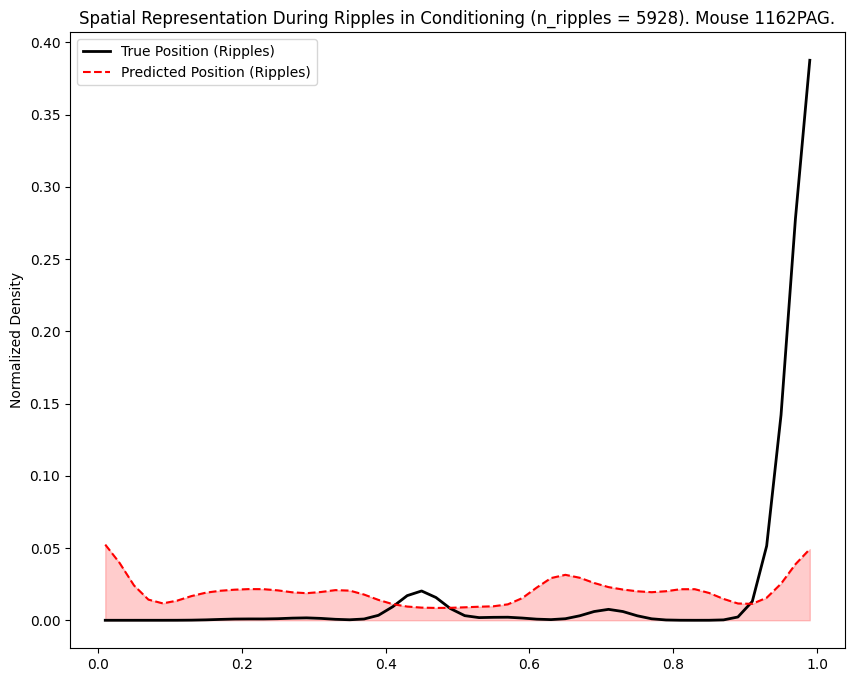

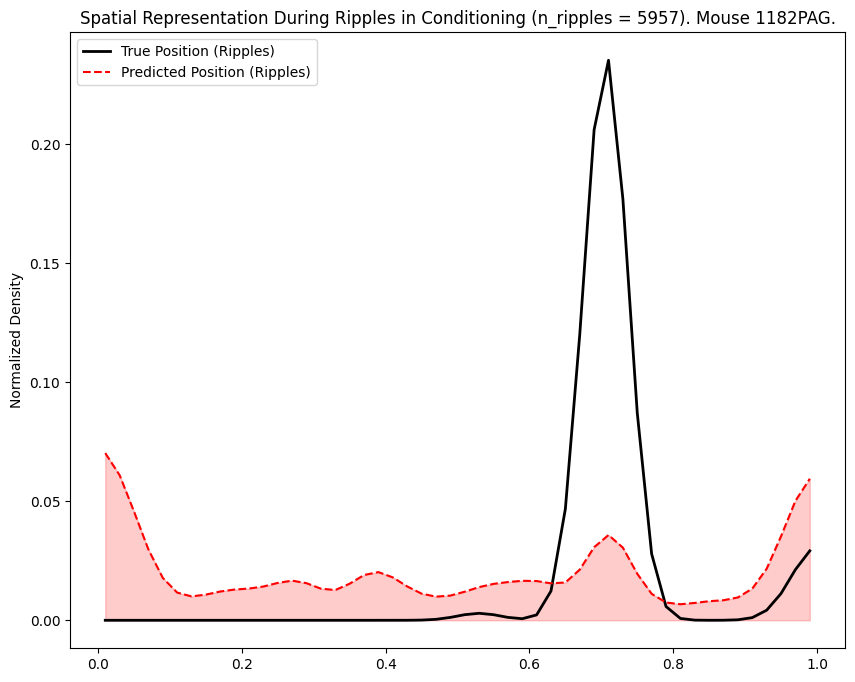

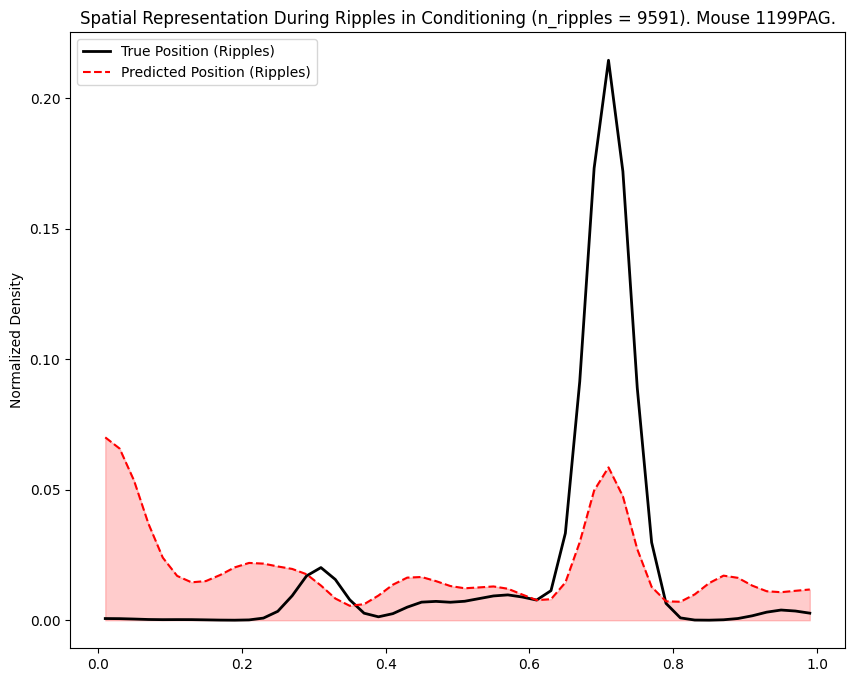

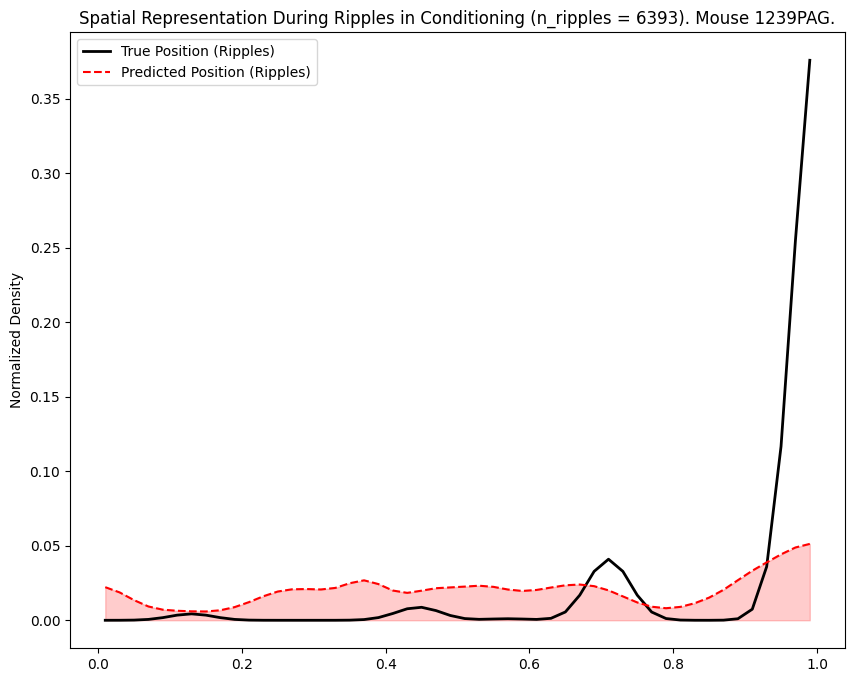

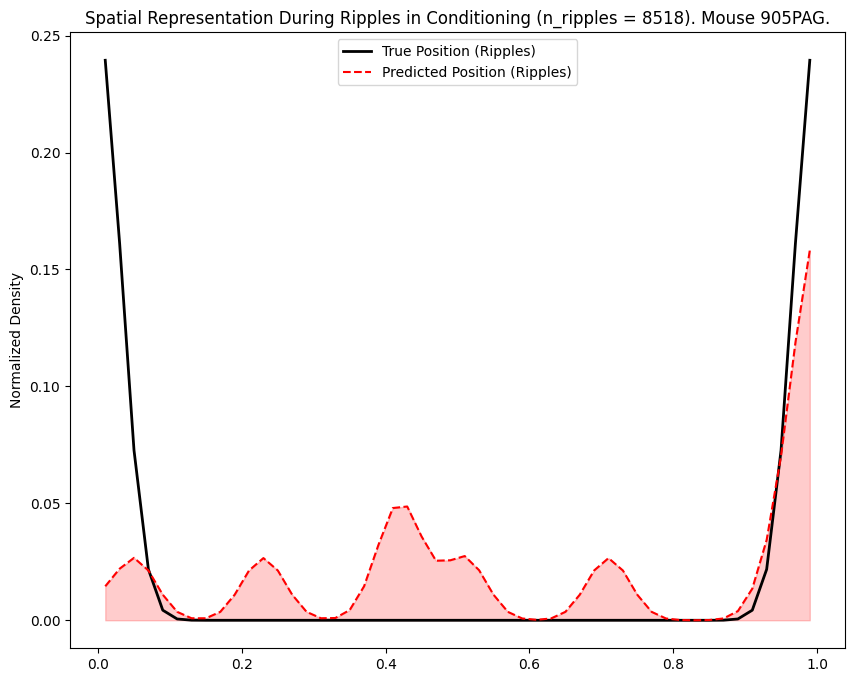

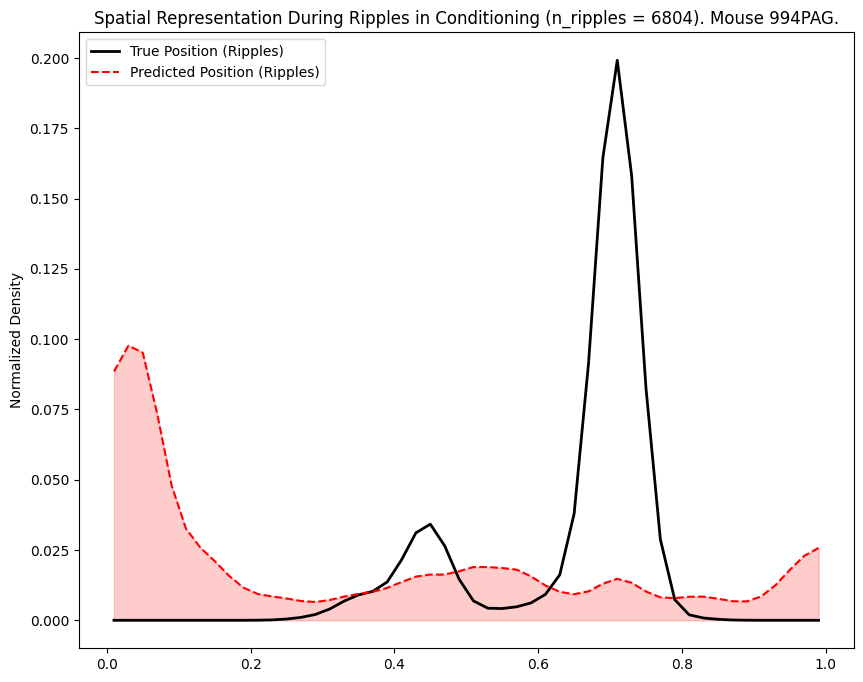

In [290]:
true_pre = []
predictions_pre = []
true_cond = []
predictions_cond = []
times_cond = []
ripples_epochs = []
is_rip = []
max_time = 0
logits_hw = []
for (mouse, manipe), df in loader.results_df.query("phase == 'pre' or phase == 'cond'").groupby(["mouse", "manipe"]):
    pre_df = df.query("phase == 'pre'")
    cond_df = df.query("phase == 'cond'")

    if len(pre_df) == 0 or len(cond_df) == 0:
        continue

    if len(pre_df) > 1 or len(cond_df) > 1:
        raise ValueError("Found several Results object.")

    pre_res = pre_df.results.iloc[0]
    cond_res = cond_df.results.iloc[0]

    true_pre.append(pre_res.resultsNN_phase["_pre"]["linearTrue"][0])
    predictions_pre.append(pre_res.resultsNN_phase["_pre"]["linearPred"][0])

    true_cond.append(cond_res.resultsNN_phase["_cond"]["linearTrue"][0])
    predictions_cond.append(cond_res.resultsNN_phase["_cond"]["linearPred"][0])

    logits_hw.append(cond_res.resultsNN_phase_pkl["_cond"]["logits_hw"][0])

    times = cond_res.resultsNN_phase["_cond"]["times"][0]
    max_time += max(times)

    times_cond.append(times + max_time)

    ripples = cond_res.DataHelper.get_ripples_epochs().values
    ripples_epochs.append(ripples + max_time)

    is_rip.append(inEpochsMask(times, ripples))

    pre_true_dens, centers = get_1d_tuning_curve(true_pre[-1], np.ones(len(true_pre[-1]), dtype=bool))
    pre_pred_dens, _       = get_1d_tuning_curve(predictions_pre[-1], np.ones(len(predictions_pre[-1]), dtype=bool))

    # --- 2. Compute Ripples Curves (Cond-phase) ---
    ripples_true_dens, _    = get_1d_tuning_curve(true_cond[-1], is_rip[-1])
    ripples_pred_dens, _    = get_1d_tuning_curve(predictions_cond[-1], is_rip[-1])
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 8), sharex=True)
    ax1.plot(centers, ripples_true_dens, label='True Position (Ripples)', color='black', lw=2)
    ax1.plot(centers, ripples_pred_dens, label='Predicted Position (Ripples)', color='red', linestyle='--')
    ax1.fill_between(centers, ripples_pred_dens, alpha=0.2, color='red')
    ax1.set_title(f'Spatial Representation During Ripples in Conditioning (n_ripples = {ripples_epochs[-1].shape[0]}). Mouse {mouse+manipe}.')
    ax1.set_ylabel('Normalized Density')
    ax1.legend()


true_pre = np.concatenate(true_pre)
predictions_pre = np.concatenate(predictions_pre)
true_cond = np.concatenate(true_cond)
predictions_cond = np.concatenate(predictions_cond)
times_cond = np.concatenate(times_cond)
ripples_epochs = np.concatenate(ripples_epochs)
is_rip = np.concatenate(is_rip)
logits_hw = np.concatenate(logits_hw)

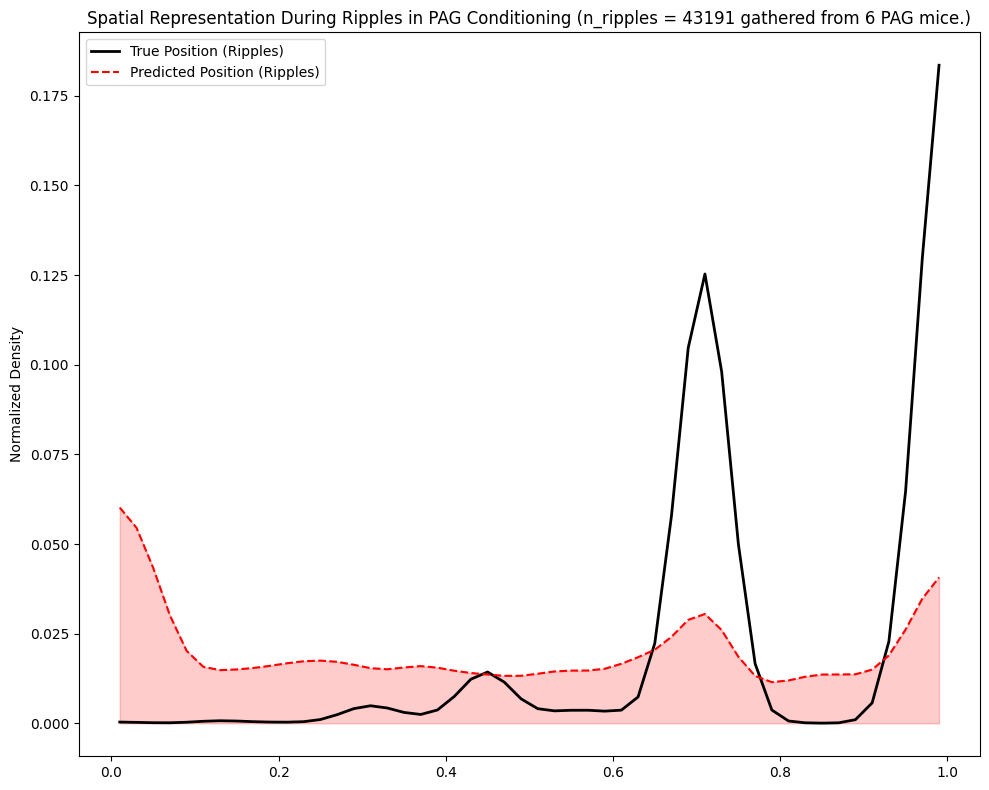

In [309]:
# --- 1. Compute Baselines (Pre-phase or Non-Ripples) ---
# We use this to see what 'normal' behavior looks like
pre_true_dens, centers = get_1d_tuning_curve(true_pre, np.ones(len(true_pre), dtype=bool))
pre_pred_dens, _       = get_1d_tuning_curve(predictions_pre, np.ones(len(predictions_pre), dtype=bool))

# --- 2. Compute Freezing Curves (Cond-phase) ---
ripples_true_dens, _    = get_1d_tuning_curve(true_cond, is_rip)
ripples_pred_dens, _    = get_1d_tuning_curve(predictions_cond, is_rip)

# --- 3. Visualization ---
fig, ax1 = plt.subplots(1, 1, figsize=(10, 8), sharex=True)

# Plot A: True vs Predicted during Freezing
ax1.plot(centers, ripples_true_dens, label='True Position (Ripples)', color='black', lw=2)
ax1.plot(centers, ripples_pred_dens, label='Predicted Position (Ripples)', color='red', linestyle='--')
ax1.fill_between(centers, ripples_pred_dens, alpha=0.2, color='red')
ax1.set_title(f'Spatial Representation During Ripples in PAG Conditioning (n_ripples = {ripples_epochs.shape[0]} gathered from {loader.results_df.query("phase == 'pre' or phase == 'cond'").groupby(["mouse", "manipe"]).count().shape[0]} PAG mice.)')
ax1.set_ylabel('Normalized Density')
ax1.legend()

# Plot B: The Deviation (Bias)
# # Deviation = (Predicted - True). Positive means decoder over-represents that location.
# bias = ripples_pred_dens - ripples_true_dens
# ax2.bar(centers, bias, width=(centers[1]-centers[0]), color='purple', alpha=0.6)
# ax2.axhline(0, color='grey', lw=1)
# ax2.set_title('Prediction Bias (Pred - True) during Freezing in Conditioning')
# ax2.set_xlabel('Linearized Position (0-1)')
# ax2.set_ylabel('Bias Delta')
plt.tight_layout()
plt.savefig(os.path.join(main_dir, "spatial_rep_ripples.png"))
plt.savefig(os.path.join(main_dir, "spatial_rep_ripples.svg"))
plt.show()

## analyse freezing reactivations

In [297]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from neuroencoders.importData.epochs_management import inEpochsMask

def get_1d_tuning_curve(positions, mask_indices, bins=50, sigma=1.5):
    """
    Generates a smoothed 1D density curve.
    Returns: (density_values, bin_centers)
    """
    # Filter data by mask (e.g., is_freeze)
    masked_data = positions[mask_indices]

    # Calculate histogram
    counts, bin_edges = np.histogram(masked_data, bins=bins, range=(0, 1))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Smooth the curve
    density = gaussian_filter1d(counts.astype(float), sigma=sigma)

    # Optional: Normalize to unit area or max (unit area is better for probability)
    if np.sum(density) > 0:
        density /= np.sum(density)

    return density, bin_centers

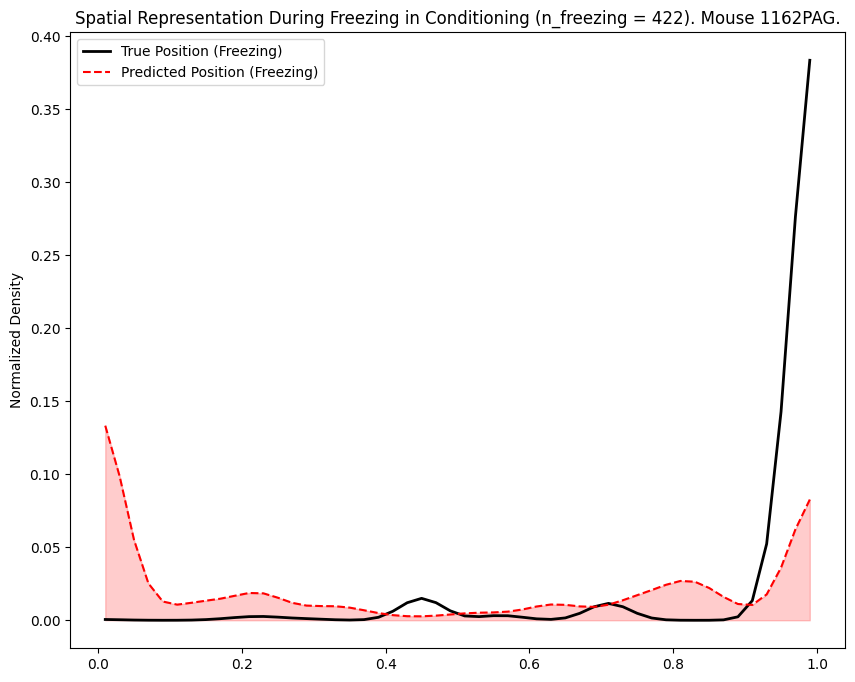

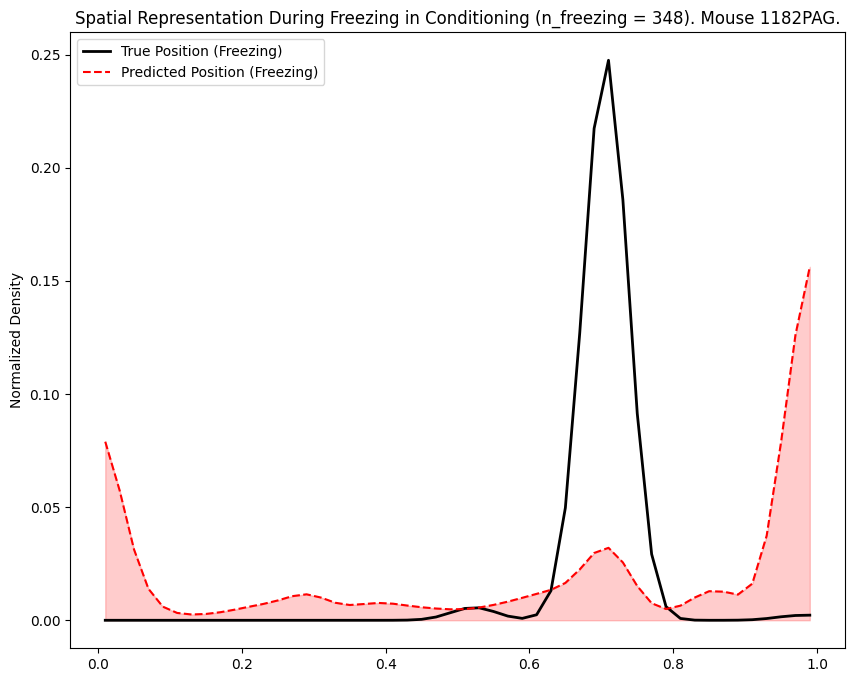

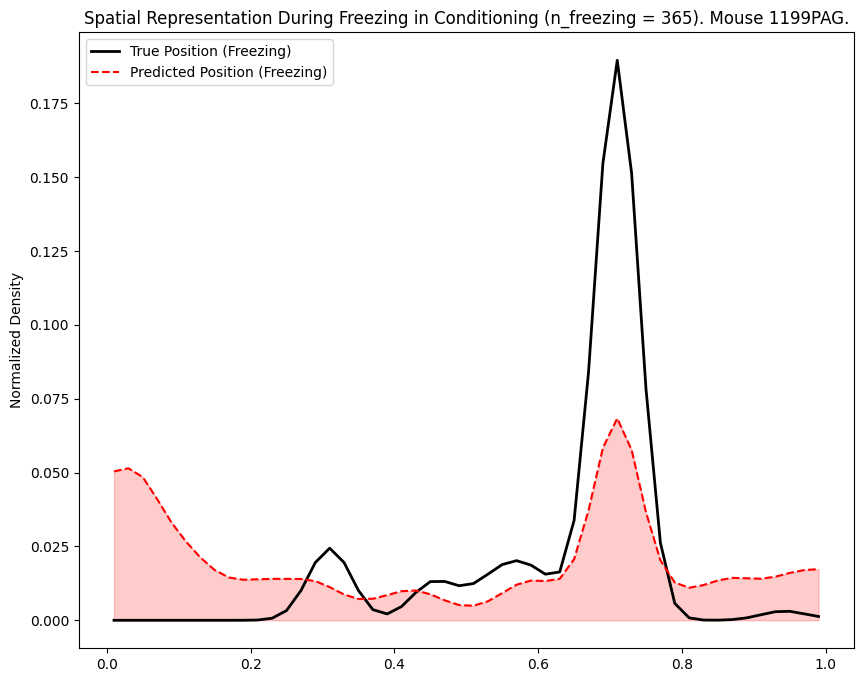

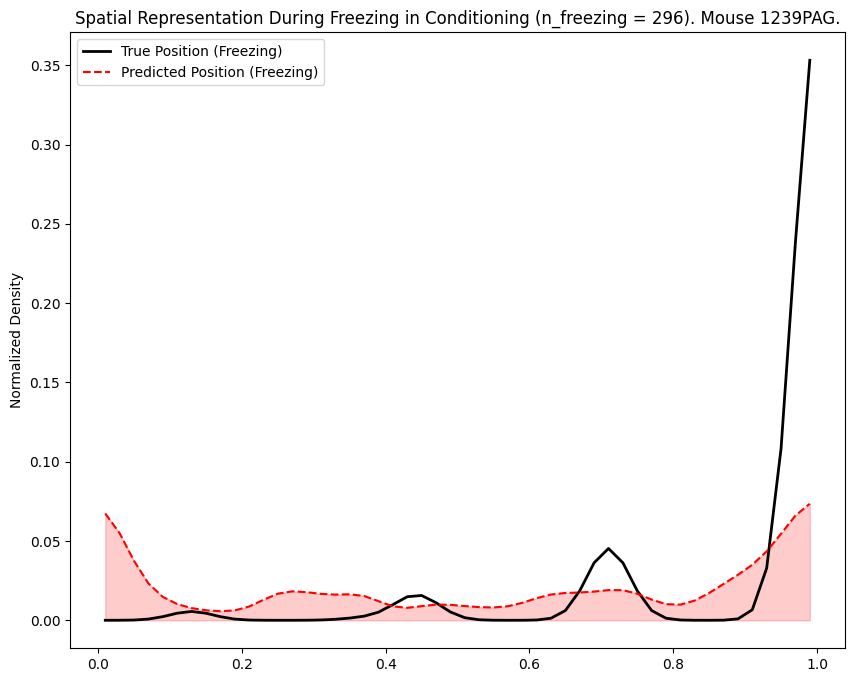

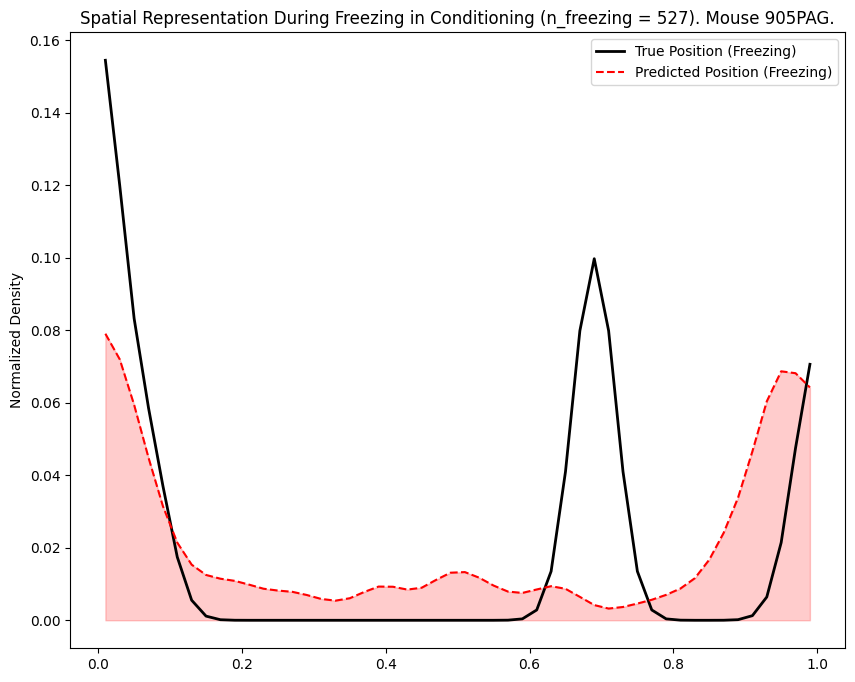

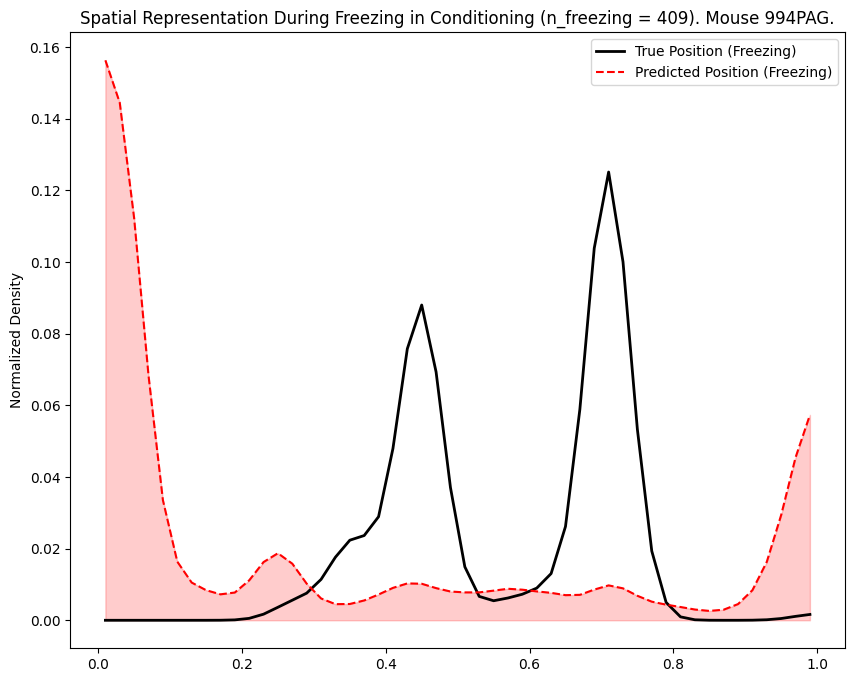

In [298]:
true_pre = []
predictions_pre = []
true_cond = []
predictions_cond = []
times_cond = []
freeze_epochs = []
is_freeze = []
max_time = 0
logits_hw = []
for (mouse, manipe), df in loader.results_df.query("phase == 'pre' or phase == 'cond'").groupby(["mouse", "manipe"]):
    pre_df = df.query("phase == 'pre'")
    cond_df = df.query("phase == 'cond'")

    if len(pre_df) == 0 or len(cond_df) == 0:
        continue

    if len(pre_df) > 1 or len(cond_df) > 1:
        raise ValueError("Found several Results object.")

    pre_res = pre_df.results.iloc[0]
    cond_res = cond_df.results.iloc[0]

    true_pre.append(pre_res.resultsNN_phase["_pre"]["linearTrue"][0])
    predictions_pre.append(pre_res.resultsNN_phase["_pre"]["linearPred"][0])

    true_cond.append(cond_res.resultsNN_phase["_cond"]["linearTrue"][0])
    predictions_cond.append(cond_res.resultsNN_phase["_cond"]["linearPred"][0])

    logits_hw.append(cond_res.resultsNN_phase_pkl["_cond"]["logits_hw"][0])

    times = cond_res.resultsNN_phase["_cond"]["times"][0]
    max_time += max(times)

    times_cond.append(times + max_time)

    freeze = cond_res.DataHelper.get_freeze_epochs().values
    freeze_epochs.append(freeze + max_time)

    is_freeze.append(inEpochsMask(times, freeze))

    pre_true_dens, centers = get_1d_tuning_curve(true_pre[-1], np.ones(len(true_pre[-1]), dtype=bool))
    pre_pred_dens, _       = get_1d_tuning_curve(predictions_pre[-1], np.ones(len(predictions_pre[-1]), dtype=bool))

    # --- 2. Compute Freezing Curves (Cond-phase) ---
    freeze_true_dens, _    = get_1d_tuning_curve(true_cond[-1], is_freeze[-1])
    freeze_pred_dens, _    = get_1d_tuning_curve(predictions_cond[-1], is_freeze[-1])
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 8), sharex=True)
    ax1.plot(centers, freeze_true_dens, label='True Position (Freezing)', color='black', lw=2)
    ax1.plot(centers, freeze_pred_dens, label='Predicted Position (Freezing)', color='red', linestyle='--')
    ax1.fill_between(centers, freeze_pred_dens, alpha=0.2, color='red')
    ax1.set_title(f'Spatial Representation During Freezing in Conditioning (n_freezing = {freeze_epochs[-1].shape[0]}). Mouse {mouse+manipe}.')
    ax1.set_ylabel('Normalized Density')
    ax1.legend()


true_pre = np.concatenate(true_pre)
predictions_pre = np.concatenate(predictions_pre)
true_cond = np.concatenate(true_cond)
predictions_cond = np.concatenate(predictions_cond)
times_cond = np.concatenate(times_cond)
freeze_epochs = np.concatenate(freeze_epochs)
is_freeze = np.concatenate(is_freeze)
logits_hw = np.concatenate(logits_hw)

In [299]:
%matplotlib inline

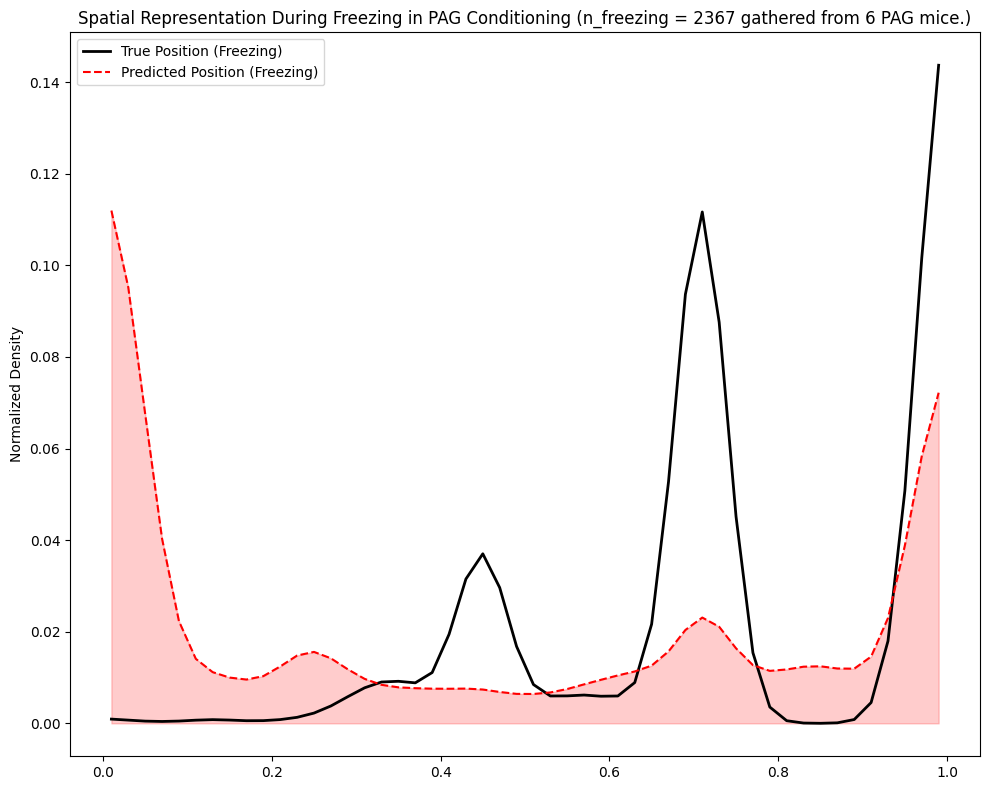

In [308]:
# --- 1. Compute Baselines (Pre-phase or Non-Freezing) ---
# We use this to see what 'normal' behavior looks like
pre_true_dens, centers = get_1d_tuning_curve(true_pre, np.ones(len(true_pre), dtype=bool))
pre_pred_dens, _       = get_1d_tuning_curve(predictions_pre, np.ones(len(predictions_pre), dtype=bool))

# --- 2. Compute Freezing Curves (Cond-phase) ---
freeze_true_dens, _    = get_1d_tuning_curve(true_cond, is_freeze)
freeze_pred_dens, _    = get_1d_tuning_curve(predictions_cond, is_freeze)

# --- 3. Visualization ---
fig, ax1 = plt.subplots(1, 1, figsize=(10, 8), sharex=True)

# Plot A: True vs Predicted during Freezing
ax1.plot(centers, freeze_true_dens, label='True Position (Freezing)', color='black', lw=2)
ax1.plot(centers, freeze_pred_dens, label='Predicted Position (Freezing)', color='red', linestyle='--')
ax1.fill_between(centers, freeze_pred_dens, alpha=0.2, color='red')
ax1.set_title(f'Spatial Representation During Freezing in PAG Conditioning (n_freezing = {freeze_epochs.shape[0]} gathered from {loader.results_df.query("phase == 'pre' or phase == 'cond'").groupby(["mouse", "manipe"]).count().shape[0]} PAG mice.)')
ax1.set_ylabel('Normalized Density')
ax1.legend()

# Plot B: The Deviation (Bias)
# # Deviation = (Predicted - True). Positive means decoder over-represents that location.
# bias = freeze_pred_dens - freeze_true_dens
# ax2.bar(centers, bias, width=(centers[1]-centers[0]), color='purple', alpha=0.6)
# ax2.axhline(0, color='grey', lw=1)
# ax2.set_title('Prediction Bias (Pred - True) during Freezing in Conditioning')
# ax2.set_xlabel('Linearized Position (0-1)')
# ax2.set_ylabel('Bias Delta')
plt.tight_layout()
plt.savefig(os.path.join(main_dir, "spatial_rep_freezing_PAG.png"))
plt.savefig(os.path.join(main_dir, "spatial_rep_freezing_PAG.svg"))
plt.show()

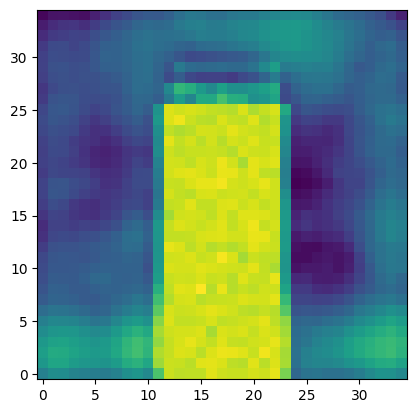

In [301]:
plt.imshow(np.median(logits_hw, axis = 0), origin = "lower" )

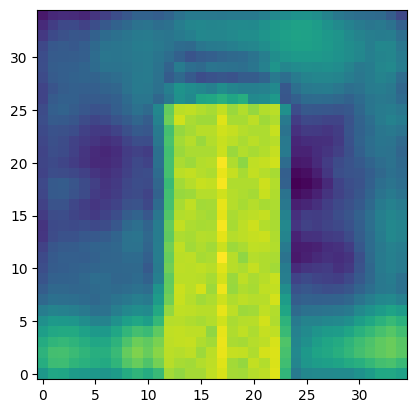

In [302]:
plt.imshow(logits_hw.mean(0), origin = "lower")

## analyse spike data during freezing/ripples

In [311]:
%matplotlib inline

In [312]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pynapple as nap

# ---------------------------
# Parameters
# ---------------------------
wi = 2.0
bin_size = 0.05
smooth_sigma = 0.05
max_fr_thresh = 150.0  # Hz: neurons above this (max FR) will be excluded as aberrant

# ---------------------------
# Helpers
# ---------------------------
import numpy as np

def _safe_zscore_on_baseline(mean_on, mean_off, baseline_mask,
                             min_std=1e-3, use_mad=True, clip_z=20.0, verbose=False):
    """
    Z-score ON/OFF using ON pre-window baseline (neuron-wise) but robust:
      - Uses regular std where available
      - If std is tiny/zero or NaN, falls back to MAD-based estimate
      - Enforces a minimum std `min_std`
      - Clips resulting z-scores to +/- clip_z
    Returns:
      mean_on_z, mean_off_z, diagnostics_dict
    diagnostics_dict contains mean_pre, std_pre, std_final, n_baseline_samples
    """
    baseline = mean_on[baseline_mask, :]  # shape: [n_baseline_times, n_neurons]
    n_baseline = np.sum(baseline_mask)

    # compute mean and std along baseline (per neuron)
    mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
    std_pre = np.nanstd(baseline, axis=0, keepdims=True)

    # MAD fallback
    if use_mad:
        med = np.nanmedian(baseline, axis=0, keepdims=True)
        mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
        mad_std = 1.4826 * mad  # approximate std from MAD
    else:
        mad_std = np.full_like(std_pre, np.nan)

    # Build a final std per neuron: take max(std_pre, mad_std, min_std)
    # but treat NaNs carefully
    combined = np.stack([
        np.where(np.isfinite(std_pre), std_pre, np.nan),
        np.where(np.isfinite(mad_std), mad_std, np.nan),
        np.full_like(std_pre, min_std)
    ], axis=0)  # shape (3, 1, n_neurons)
    # max across axis=0 ignoring NaNs
    with np.errstate(invalid="ignore"):
        std_final = np.nanmax(combined, axis=0)  # shape (1, n_neurons)

    # replace any remaining nans with min_std
    std_final = np.where(np.isfinite(std_final), std_final, min_std)

    # compute z-scores
    mean_on_z = (mean_on - mean_pre) / std_final
    mean_off_z = (mean_off - mean_pre) / std_final

    # clip extremes (avoid 1e63 etc)
    mean_on_z = np.clip(mean_on_z, -clip_z, clip_z)
    mean_off_z = np.clip(mean_off_z, -clip_z, clip_z)

    # diagnostics
    diagnostics = {
        "n_baseline_samples": int(n_baseline),
        "mean_pre_min": float(np.nanmin(mean_pre)) if np.isfinite(np.nanmin(mean_pre)) else np.nan,
        "mean_pre_max": float(np.nanmax(mean_pre)) if np.isfinite(np.nanmax(mean_pre)) else np.nan,
        "std_pre_min": float(np.nanmin(std_pre)) if np.isfinite(np.nanmin(std_pre)) else np.nan,
        "std_pre_median": float(np.nanmedian(std_pre)) if np.isfinite(np.nanmedian(std_pre)) else np.nan,
        "std_final_min": float(np.nanmin(std_final)) if np.isfinite(np.nanmin(std_final)) else np.nan,
        "n_neurons": mean_on.shape[1],
        "n_small_std": int(np.sum(std_final.flatten() <= min_std))
    }
    if verbose:
        print("Baseline samples:", diagnostics["n_baseline_samples"])
        print("mean_pre [min,max]:", diagnostics["mean_pre_min"], diagnostics["mean_pre_max"])
        print("std_pre [min,median]:", diagnostics["std_pre_min"], diagnostics["std_pre_median"])
        print("std_final_min:", diagnostics["std_final_min"], "n_small_std:", diagnostics["n_small_std"])

    return mean_on_z, mean_off_z, diagnostics


def compute_freeze_onoff_for_mouse(
    mouse_results, wi=2.0, bin_size=0.05, smooth_sigma=0.05, max_fr_thresh=150.0, verbose = True
):
    """
    Returns dict with:
      - sorted_heatmap: shape [time_on+time_off, n_neurons] (sorted by ON response)
      - keep_sorted: bool mask of kept neurons in sorted order
      - sort_idx: sorting indices
      - n_neurons_raw
      - n_aberrant
    Neurons with max FR > max_fr_thresh (Hz) are treated as aberrant and excluded.
    """
    try:
        spikes = mouse_results.DataHelper.get_spike_data()
    except FileNotFoundError:
        if os.path.isfile(os.path.join(mouse_results.network_path, "SpikeData.mat")):
            print("copying spike data from server")
            import shutil

            shutil.copyfile(
                os.path.join(mouse_results.network_path, "SpikeData.mat"),
                os.path.join(mouse_results.DataHelper.folder, "SpikeData.mat"),
            )
            spikes = mouse_results.DataHelper.get_spike_data()
        else:
            raise

    cond_epoch = nap.IntervalSet(mouse_results.cond)

    freeze_epochs = mouse_results.DataHelper.get_freeze_epochs().intersect(cond_epoch)
    if len(freeze_epochs) == 0:
        return None

    counts = spikes.count(bin_size)
    fr = counts / bin_size  # average firing rate per bin (TsdFrame-like)

    # compute per-neuron max FR across session to detect aberrant neurons
    try:
        fr_values = fr.values.astype(float)  # shape: [time, neurons]
    except Exception:
        # fallback if .values isn't available
        fr_values = np.array(fr).astype(float)

    n_neurons_raw = fr_values.shape[1] if fr_values.ndim == 2 else 0
    max_fr_per_neuron = np.nanmax(fr_values, axis=0)
    aberrant_mask = max_fr_per_neuron > max_fr_thresh
    n_aberrant = int(np.sum(aberrant_mask))
    valid_mask = ~aberrant_mask

    if valid_mask.sum() == 0:
        # no valid neurons left
        print("All neurons flagged as aberrant (FR > {}). skipping.".format(max_fr_thresh))
        return None

    # Smooth FR (smoothing will ignore NaNs introduced below)
    # We do not modify fr_values in place; we'll drop aberrant neurons later on PETH outputs
    z_fr = fr.smooth(smooth_sigma)

    # PETH on onset and offset within conditioning epoch
    onsets = nap.Ts(freeze_epochs.start)
    offsets = nap.Ts(freeze_epochs.end)

    peth_on = nap.compute_perievent(z_fr, onsets, window=(-wi, wi), epochs=cond_epoch)
    peth_off = nap.compute_perievent(z_fr, offsets, window=(-wi, wi), epochs=cond_epoch)

    # Average across events => [time, neuron]
    mean_on = peth_on.mean(axis=1).values.astype(float)
    mean_off = peth_off.mean(axis=1).values.astype(float)

    mean_on[np.isinf(mean_on)] = np.nan
    mean_off[np.isinf(mean_off)] = np.nan

    # Set aberrant neurons to NaN in PETH arrays so they are excluded downstream
    if mean_on.shape[1] != n_neurons_raw:
        # Sanity: shapes mismatch (e.g. spike grouping differences). Try to handle gracefully.
        # If mismatch, recompute n_neurons_raw from peth arrays:
        n_neurons_raw = mean_on.shape[1]
        max_fr_per_neuron = max_fr_per_neuron[:n_neurons_raw]
        valid_mask = max_fr_per_neuron <= max_fr_thresh
        aberrant_mask = ~valid_mask
        n_aberrant = int(np.sum(aberrant_mask))

    mean_on[:, aberrant_mask] = np.nan
    mean_off[:, aberrant_mask] = np.nan

    t_on = peth_on.times()
    baseline_mask = t_on <= -0.5
    if not np.any(baseline_mask):
        return None

    mean_on, mean_off, diag = _safe_zscore_on_baseline(mean_on, mean_off, baseline_mask)
    if verbose:
        print(diag)
    mean_on[np.isinf(mean_on)] = np.nan
    mean_off[np.isinf(mean_off)] = np.nan

    # Same sorting window as your code
    times_mask = (t_on >= -0.05) & (t_on <= 1.9)
    if not np.any(times_mask):
        return None

    sort_idx = np.argsort(np.nanmean(mean_on[times_mask], axis=0))

    keep_neurons_on = ~np.isnan(mean_on).all(axis=0)
    keep_neurons_off = ~np.isnan(mean_off).all(axis=0)
    keep_neurons = keep_neurons_on | keep_neurons_off

    # ensure aberrant neurons are not marked as kept
    keep_neurons[aberrant_mask] = False

    full_response = np.vstack([mean_on, mean_off])  # [2*time, neurons]
    sorted_heatmap = full_response[:, sort_idx]
    keep_sorted = keep_neurons[sort_idx]

    return {
        "sorted_heatmap": sorted_heatmap,
        "keep_sorted": keep_sorted,
        "sort_idx": sort_idx,
        "n_neurons_raw": int(n_neurons_raw),
        "n_aberrant": int(n_aberrant),
        "peth_on": peth_on,
        "peth_off": peth_off
    }


# plotting functions unchanged (copy from your previous code)
def plot_mouse_heatmap(result, mouse_label, wi=2.0, cmap="viridis"):
    hm = result["sorted_heatmap"]
    keep = result["keep_sorted"]
    hm_plot = hm[:, keep].T  # [neurons, time]

    plt.figure(figsize=(6, 6))
    plt.imshow(
        hm_plot,
        origin="lower",
        aspect="auto",
        extent=(-wi, 3 * wi, 0, hm_plot.shape[0]),
        cmap=cmap,
    )
    plt.colorbar(label="Mean z-score FR")
    plt.axvline(0, color="yellow", label="Freezing onset")
    plt.axvline(2 * wi, color="red", label="Freezing offset")
    plt.xlabel("Time from freezing onset (s)")
    plt.ylabel("Neuron index")
    plt.title(f"{mouse_label} - ON/OFF freezing modulation")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3714164/831556468.py:35: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3714164/831556468.py:40: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_3714164/831556468.py:41: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_3714164/831556468.py:189: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_on[times_mask], axis=0))


{'n_baseline_samples': 31, 'mean_pre_min': 0.005288207297677739, 'mean_pre_max': 17.4949557627556, 'std_pre_min': 0.014717802668191842, 'std_pre_median': 0.20484841162803674, 'std_final_min': 0.001, 'n_neurons': 57, 'n_small_std': 19}
[ok] mouse 1162 | PAG: raw neurons=57, kept=38


/tmp/ipykernel_3714164/831556468.py:35: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3714164/831556468.py:40: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_3714164/831556468.py:41: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_3714164/831556468.py:189: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_on[times_mask], axis=0))


{'n_baseline_samples': 31, 'mean_pre_min': 0.006937218175511619, 'mean_pre_max': 9.78478704921186, 'std_pre_min': 0.01930722718124718, 'std_pre_median': 0.23625843368665805, 'std_final_min': 0.001, 'n_neurons': 51, 'n_small_std': 19}
[ok] mouse 1182 | PAG: raw neurons=51, kept=32


/tmp/ipykernel_3714164/831556468.py:35: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3714164/831556468.py:40: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_3714164/831556468.py:41: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_3714164/831556468.py:189: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_on[times_mask], axis=0))


...

{'n_baseline_samples': 31, 'mean_pre_min': 7.929783711385466e-66, 'mean_pre_max': 9.48997252339346, 'std_pre_min': 4.343321302163251e-65, 'std_pre_median': 0.34025834241735375, 'std_final_min': 0.001, 'n_neurons': 78, 'n_small_std': 25}
[ok] mouse 1239 | PAG: raw neurons=78, kept=55


/tmp/ipykernel_3714164/831556468.py:35: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3714164/831556468.py:40: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_3714164/831556468.py:41: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_3714164/831556468.py:189: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_on[times_mask], axis=0))


{'n_baseline_samples': 31, 'mean_pre_min': 0.0072840723309493425, 'mean_pre_max': 4.205021756153091, 'std_pre_min': 0.020163177503116567, 'std_pre_median': 0.15657464750815106, 'std_final_min': 0.001, 'n_neurons': 34, 'n_small_std': 8}
[ok] mouse 905 | PAG: raw neurons=34, kept=26


/tmp/ipykernel_3714164/831556468.py:35: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3714164/831556468.py:40: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_3714164/831556468.py:41: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_3714164/831556468.py:189: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_on[times_mask], axis=0))


{'n_baseline_samples': 31, 'mean_pre_min': 4.23054271588741e-40, 'mean_pre_max': 4.854401114837865, 'std_pre_min': 2.3171603932842004e-39, 'std_pre_median': 0.21010715485587395, 'std_final_min': 0.001, 'n_neurons': 96, 'n_small_std': 20}
[ok] mouse 994 | PAG: raw neurons=96, kept=77


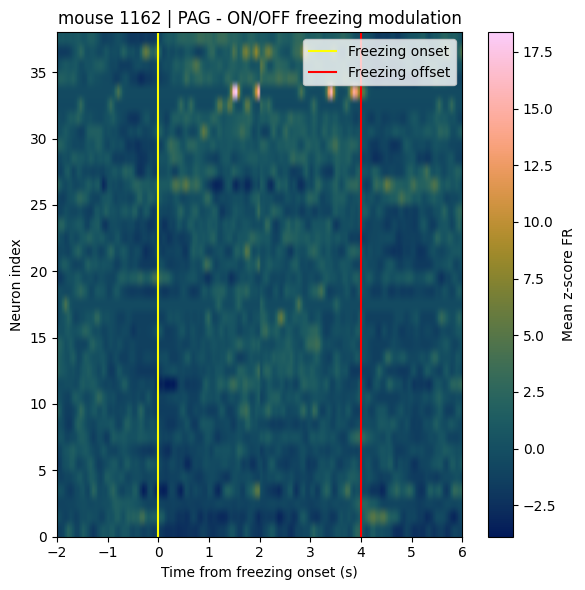

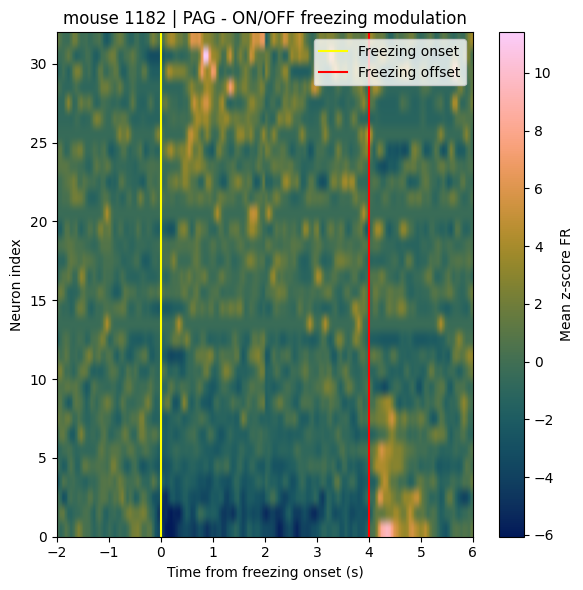

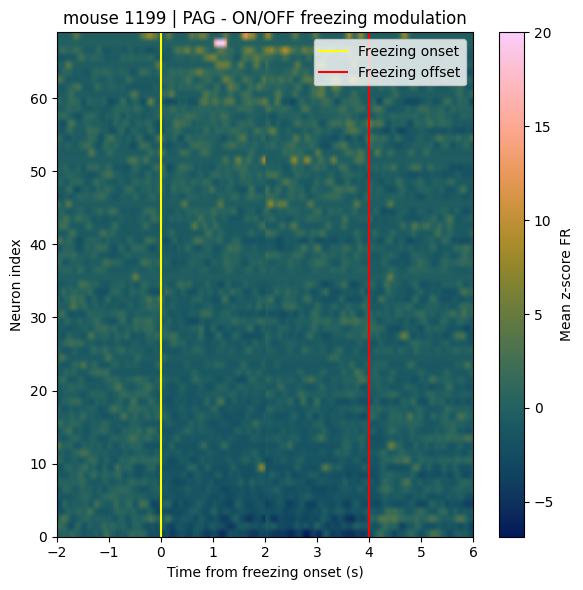

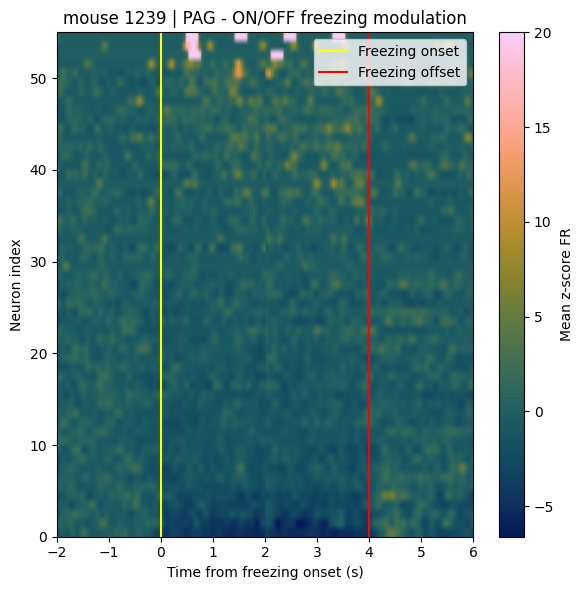

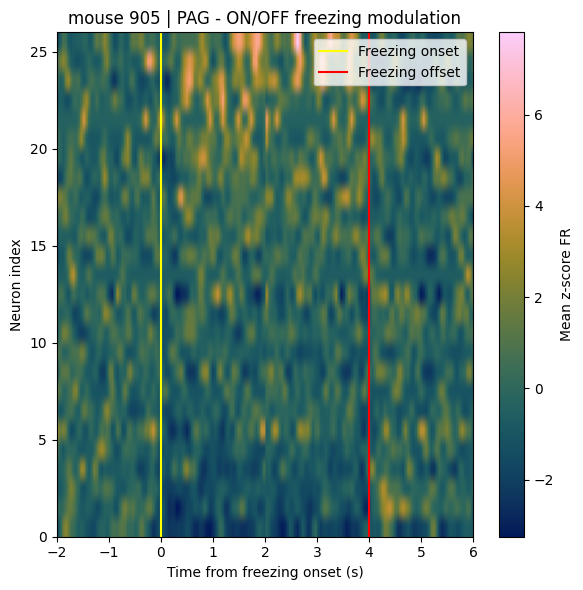

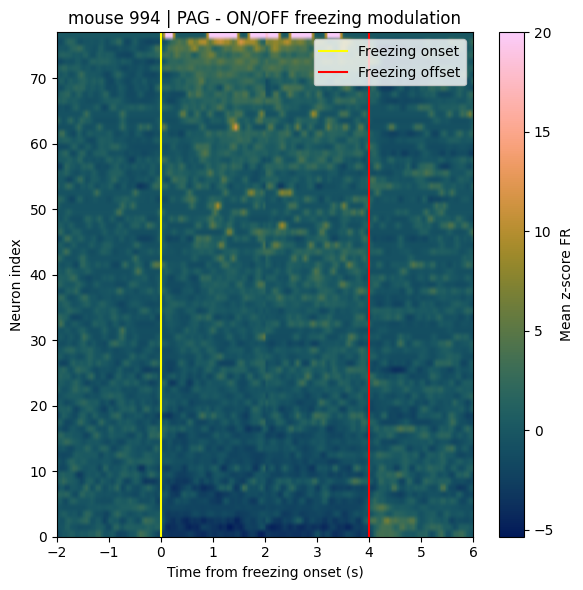

In [313]:
# ---------------------------
# Main loop over all mice
# ---------------------------
# Expecting each row's .results to be a Mouse_Results-like object
# You can adjust the query/grouping if your dataframe uses different columns.
results_by_mouse = []

for (mouse, manipe), df in loader.results_df.groupby(["mouse", "manipe"]):
    # pick one result object per mouse/manipe group
    mouse_results = df.iloc[0].results
    mouse_label = f"mouse {mouse} | {manipe}"

    out = compute_freeze_onoff_for_mouse(
        mouse_results,
        wi=wi,
        bin_size=bin_size,
        smooth_sigma=smooth_sigma,
    )
    if out is None:
        print(f"[skip] {mouse_label}: no valid freeze/cond data")
        continue

    print(
        f"[ok] {mouse_label}: raw neurons={out['n_neurons_raw']}, "
        f"kept={out['keep_sorted'].sum()}"
    )
    results_by_mouse.append((mouse_label, out))

# 1) Plot per mouse
for mouse_label, out in results_by_mouse:
    plot_mouse_heatmap(out, mouse_label, wi=wi, cmap="cmc.batlow")  # or "viridis"

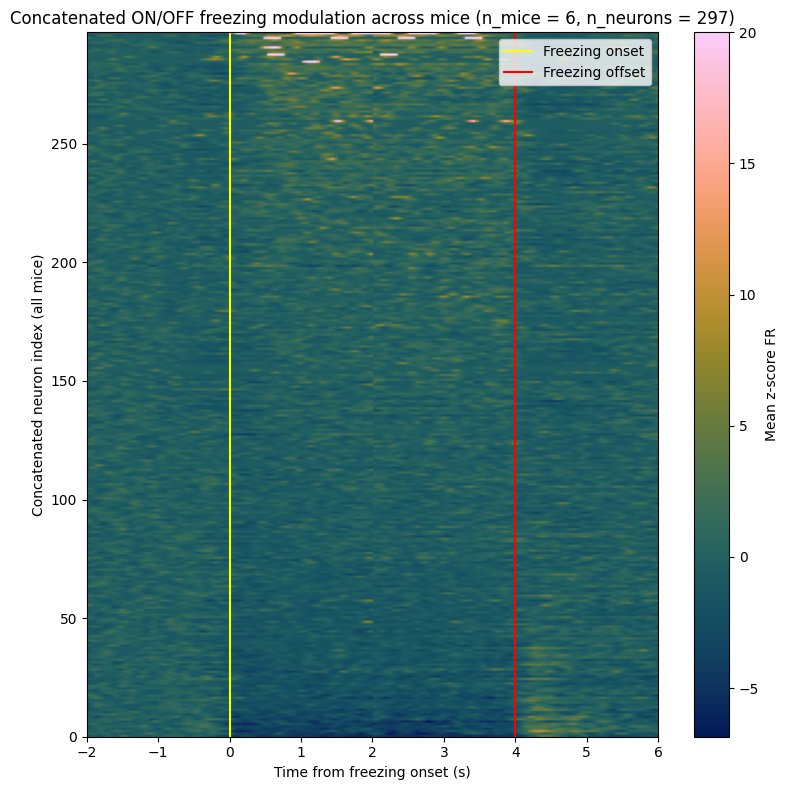

In [314]:
def plot_concatenated_heatmap(results_by_mouse, wi=2.0, cmap="viridis", sort = True, dir = None):
    blocks = []
    for mouse_label, result in results_by_mouse:
        hm = result["sorted_heatmap"][:, result["keep_sorted"]].T  # [neurons, time]
        if hm.shape[0] > 0:
            blocks.append(hm)

    if len(blocks) == 0:
        print("No valid mouse heatmaps to concatenate.")
        return

    concat_hm = np.vstack(blocks)  # stack neurons from all mice
    time = np.linspace(-wi, 3 * wi, concat_hm.shape[1])

    if sort:
        times_mask = (time >= -0.05) & (time <= 1.9)
        sort_map = np.argsort(concat_hm[:, times_mask].mean(1))
        concat_hm = concat_hm[sort_map]

    plt.figure(figsize=(8, 8))
    plt.imshow(
        concat_hm,
        origin="lower",
        aspect="auto",
        extent=(-wi, 3 * wi, 0, concat_hm.shape[0]),
        cmap=cmap,
    )
    plt.colorbar(label="Mean z-score FR")
    plt.axvline(0, color="yellow", label="Freezing onset")
    plt.axvline(2 * wi, color="red", label="Freezing offset")
    plt.xlabel("Time from freezing onset (s)")
    plt.ylabel("Concatenated neuron index (all mice)")
    plt.title(f"Concatenated ON/OFF freezing modulation across mice (n_mice = {len(results_by_mouse)}, n_neurons = {concat_hm.shape[0]})")
    plt.legend(loc="upper right")
    plt.tight_layout()
    if dir is not None:
        plt.savefig(os.path.join(dir, "spike_data_freezing.png"))
        plt.savefig(os.path.join(dir, "spike_data_freezing.svg"))
    plt.show()

    return concat_hm

concat_hm = plot_concatenated_heatmap(results_by_mouse, wi=wi, cmap="cmc.batlow", dir = main_dir)

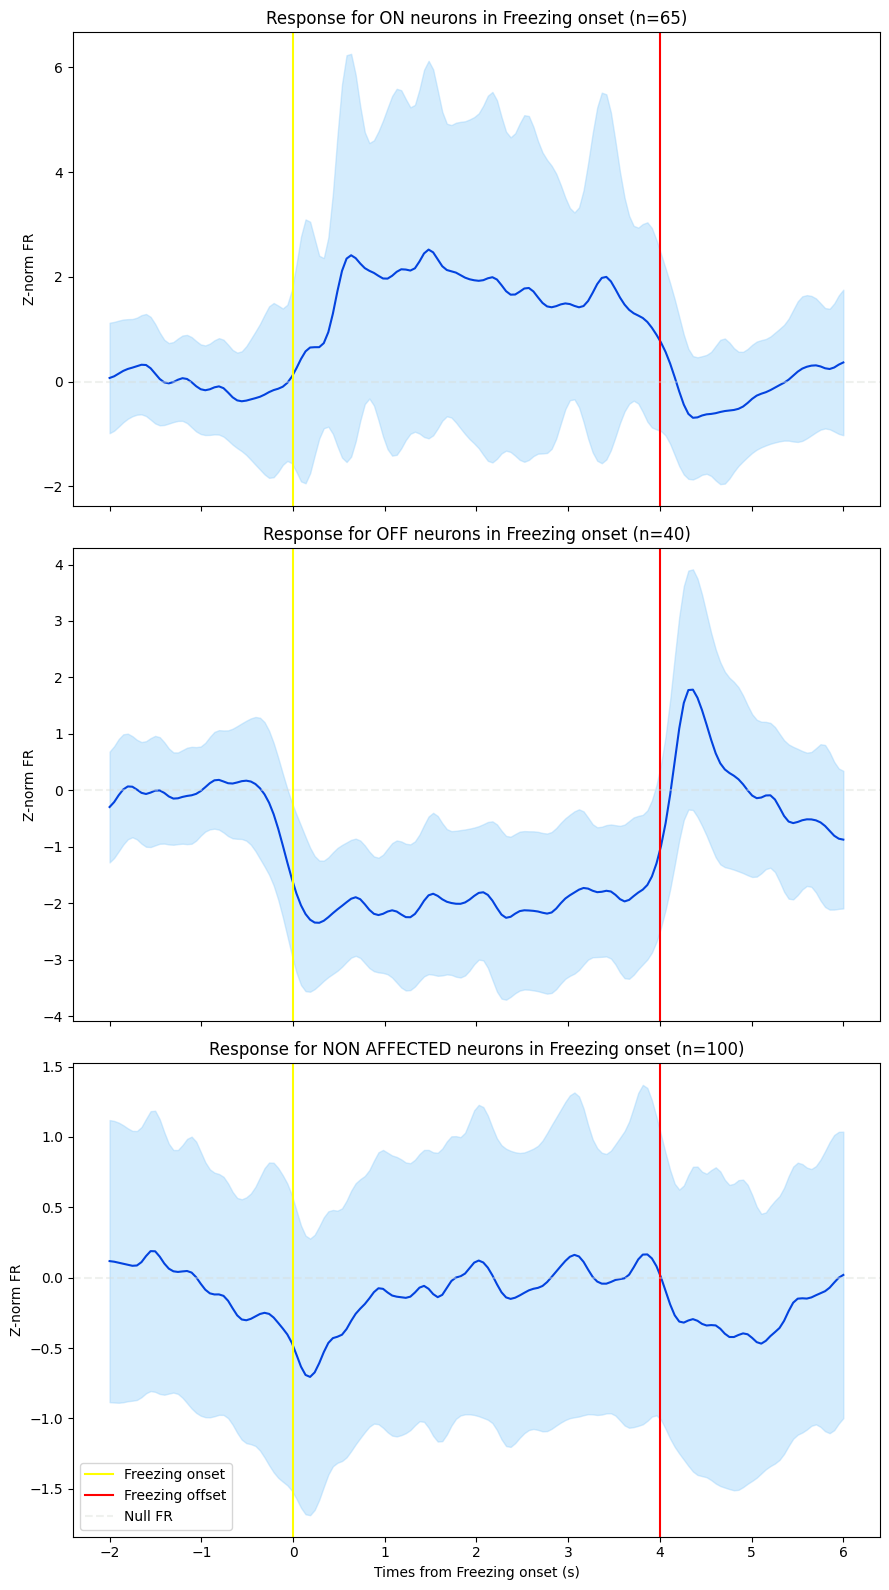

In [315]:
from scipy.ndimage import gaussian_filter

sigma = 1.5

time = np.linspace(-wi, 3*wi, concat_hm.shape[1])
times_mask = (time >= -0.05) & (time <= 1.9)
sort_map = np.argsort(concat_hm[:, times_mask].mean(1))
concat_hm = concat_hm[sort_map]

freezing_response = concat_hm
on_neurons_freezing = sort_map[-65:]
off_neurons_freezing = sort_map[:40]
not_affected_neurons_freezing = sort_map[80:180]
on_response = freezing_response[on_neurons_freezing]
off_response = freezing_response[off_neurons_freezing]
no_response = freezing_response[not_affected_neurons_freezing]
# show mean response for on and off

fig, axs = plt.subplots(3, sharex = True, sharey = False, figsize = (9,16))
axs = axs.flatten()
times = np.linspace(- wi, 3*wi, on_response.shape[1])
for i, (response, status) in enumerate(zip([on_response, off_response, no_response], ["on", "off", "non affected"])):
    mean = gaussian_filter(np.nanmean(response, axis=0), sigma = sigma)
    std = gaussian_filter(np.nanstd(response, axis=0), sigma = sigma)
    # first, plot individual traces in light grey
    # for resp in response:
    #     axs[i].plot(times, resp, color = "xkcd:light grey", alpha = 0.4)
    axs[i].plot(times, mean, color = "xkcd:blue")
    axs[i].fill_between(times, mean - 1*std, mean + 1*std, color = "xkcd:light blue", alpha = 0.4)
    axs[i].set_title(f"Response for {status.upper()} neurons in Freezing onset (n={response.shape[0]})")
    axs[i].axvline(0, label = "Freezing onset", color = "yellow")
    axs[i].axvline(2*wi, label = "Freezing offset", color = "red")
    axs[i].set_ylabel("Z-norm FR")
    axs[i].axhline(0, label = "Null FR", linestyle = "--", alpha = 0.4, color = "xkcd:light grey")

axs[-1].set_xlabel("Times from Freezing onset (s)")
axs[-1].legend()
fig.tight_layout()
fig.savefig(
    os.path.join(main_dir, "ONOFF_Freezing_neurons.png")
)
fig.savefig(
    os.path.join(main_dir, "ONOFF_Freezing_neurons.svg")
)
plt.show()

In [331]:
main_dir

'/home/mickey/Dropbox/Mobs_member/Theotime_De_Charrin/Figures/Pres180526'

## analyse spike data during ripples

/tmp/ipykernel_3714164/3484740856.py:27: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3714164/3484740856.py:31: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_3714164/3484740856.py:32: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_3714164/3484740856.py:168: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_ripple[times_mask], axis=0))


[ok] mouse 1162 | PAG: raw neurons=57, aberrant=19, kept=38, ripples=732


/tmp/ipykernel_3714164/3484740856.py:27: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3714164/3484740856.py:31: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_3714164/3484740856.py:32: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_3714164/3484740856.py:168: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_ripple[times_mask], axis=0))


[ok] mouse 1182 | PAG: raw neurons=51, aberrant=19, kept=32, ripples=423


/tmp/ipykernel_3714164/3484740856.py:27: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3714164/3484740856.py:31: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_3714164/3484740856.py:32: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_3714164/3484740856.py:168: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_ripple[times_mask], axis=0))


...

/tmp/ipykernel_3714164/3484740856.py:27: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3714164/3484740856.py:31: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_3714164/3484740856.py:32: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_3714164/3484740856.py:168: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_ripple[times_mask], axis=0))


[ok] mouse 1239 | PAG: raw neurons=78, aberrant=23, kept=55, ripples=327


/tmp/ipykernel_3714164/3484740856.py:27: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3714164/3484740856.py:31: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_3714164/3484740856.py:32: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_3714164/3484740856.py:168: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_ripple[times_mask], axis=0))


[ok] mouse 905 | PAG: raw neurons=34, aberrant=8, kept=26, ripples=357
[ok] mouse 994 | PAG: raw neurons=96, aberrant=19, kept=77, ripples=340


/tmp/ipykernel_3714164/3484740856.py:27: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_3714164/3484740856.py:31: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_3714164/3484740856.py:32: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_3714164/3484740856.py:168: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_ripple[times_mask], axis=0))


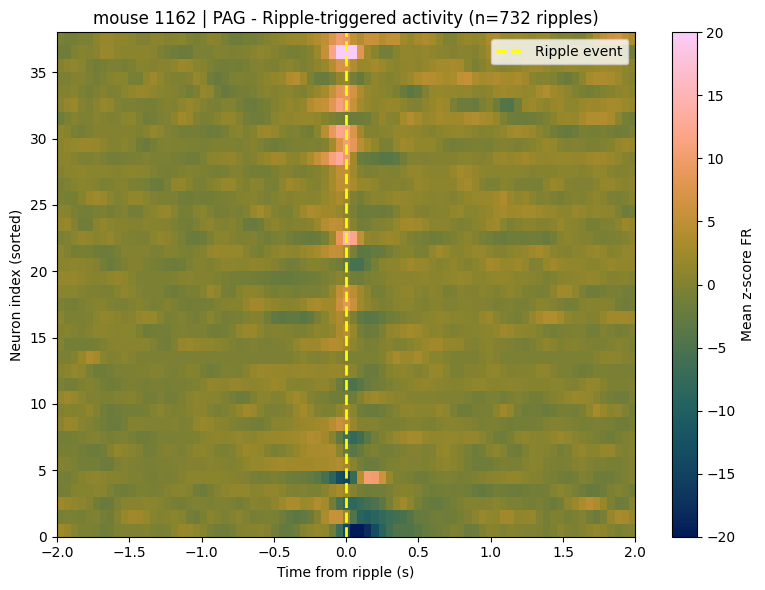

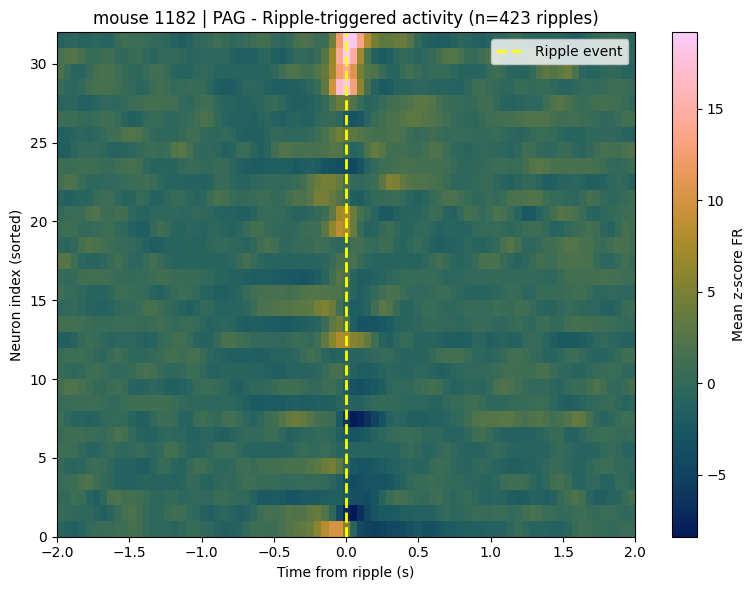

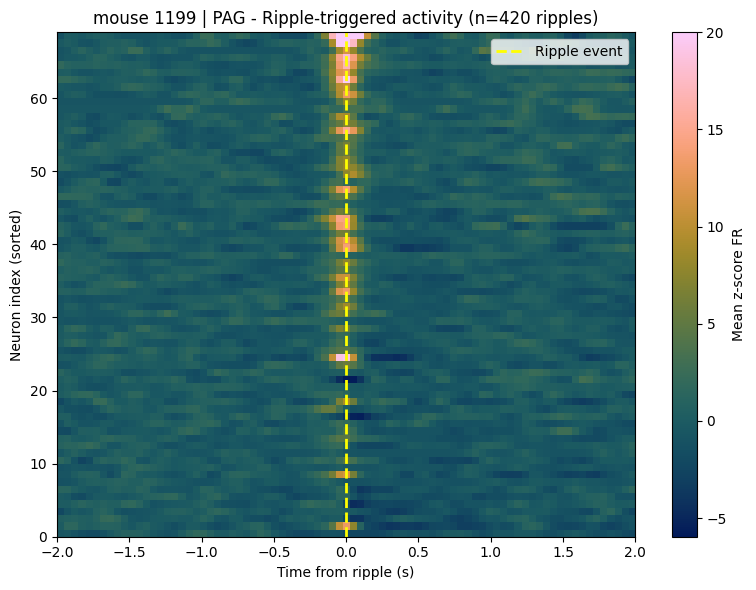

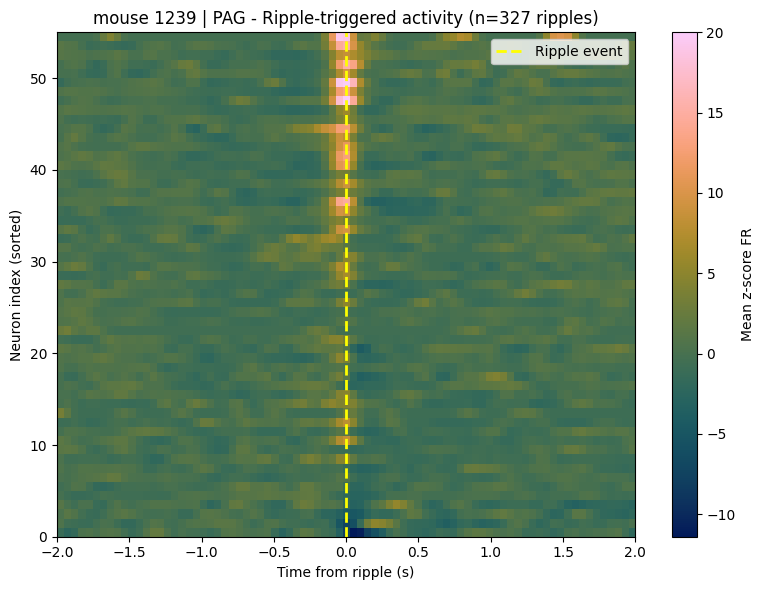

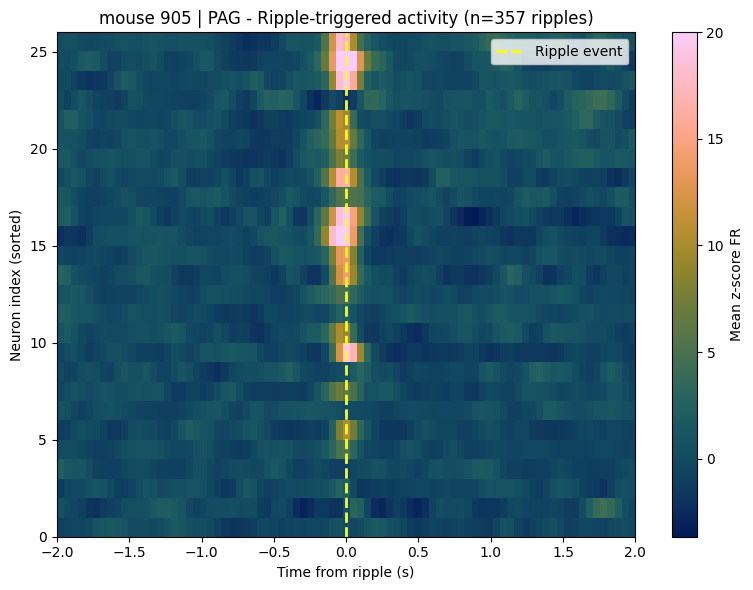

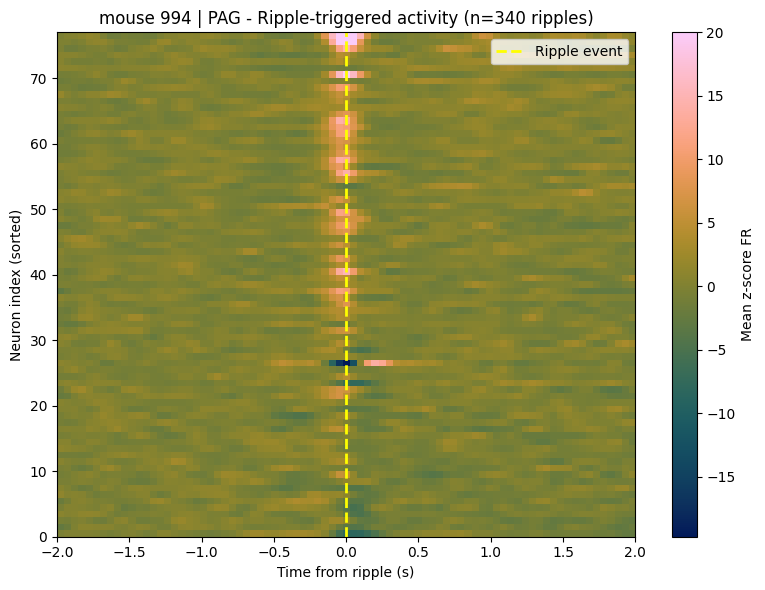

In [322]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pynapple as nap

# ---------------------------
# Parameters
# ---------------------------
wi = 2.0  # window around event
bin_size = 0.05
smooth_sigma = 0.05
max_fr_thresh = 150.0  # Hz
min_std = 1e-3
clip_z = 20.0

# ---------------------------
# Helpers (unchanged from freezing pipeline)
# ---------------------------
def _safe_zscore_on_baseline(mean_ripple, baseline_mask,
                             min_std=1e-3, use_mad=True, clip_z=20.0, verbose=False):
    """
    Z-score ripple response using pre-window baseline (neuron-wise) but robust.
    """
    baseline = mean_ripple[baseline_mask, :]  # shape: [n_baseline_times, n_neurons]
    n_baseline = np.sum(baseline_mask)

    mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
    std_pre = np.nanstd(baseline, axis=0, keepdims=True)

    if use_mad:
        med = np.nanmedian(baseline, axis=0, keepdims=True)
        mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
        mad_std = 1.4826 * mad
    else:
        mad_std = np.full_like(std_pre, np.nan)

    combined = np.stack([
        np.where(np.isfinite(std_pre), std_pre, np.nan),
        np.where(np.isfinite(mad_std), mad_std, np.nan),
        np.full_like(std_pre, min_std)
    ], axis=0)
    with np.errstate(invalid="ignore"):
        std_final = np.nanmax(combined, axis=0)

    std_final = np.where(np.isfinite(std_final), std_final, min_std)

    mean_ripple_z = (mean_ripple - mean_pre) / std_final
    mean_ripple_z = np.clip(mean_ripple_z, -clip_z, clip_z)

    diagnostics = {
        "n_baseline_samples": int(n_baseline),
        "mean_pre_min": float(np.nanmin(mean_pre)) if np.isfinite(np.nanmin(mean_pre)) else np.nan,
        "mean_pre_max": float(np.nanmax(mean_pre)) if np.isfinite(np.nanmax(mean_pre)) else np.nan,
        "std_pre_min": float(np.nanmin(std_pre)) if np.isfinite(np.nanmin(std_pre)) else np.nan,
        "std_pre_median": float(np.nanmedian(std_pre)) if np.isfinite(np.nanmedian(std_pre)) else np.nan,
        "std_final_min": float(np.nanmin(std_final)) if np.isfinite(np.nanmin(std_final)) else np.nan,
        "n_neurons": mean_ripple.shape[1],
        "n_small_std": int(np.sum(std_final.flatten() <= min_std))
    }
    if verbose:
        print("Baseline samples:", diagnostics["n_baseline_samples"])
        print("mean_pre [min,max]:", diagnostics["mean_pre_min"], diagnostics["mean_pre_max"])
        print("std_pre [min,median]:", diagnostics["std_pre_min"], diagnostics["std_pre_median"])
        print("std_final_min:", diagnostics["std_final_min"], "n_small_std:", diagnostics["n_small_std"])

    return mean_ripple_z, diagnostics


def compute_ripple_eta_for_mouse(
    mouse_results, wi=2.0, bin_size=0.05, smooth_sigma=0.05, max_fr_thresh=150.0
):
    """
    Compute event-triggered average (ETA) around ripple events.
    Returns dict with:
      - heatmap: shape [time, n_neurons] (sorted by ripple response)
      - keep_sorted: bool mask of kept neurons in sorted order
      - sort_idx: sorting indices
      - n_neurons_raw
      - n_aberrant
    Neurons with max FR > max_fr_thresh (Hz) are treated as aberrant and excluded.
    """
    try:
        spikes = mouse_results.DataHelper.get_spike_data()
    except FileNotFoundError:
        if os.path.isfile(os.path.join(mouse_results.network_path, "SpikeData.mat")):
            print("copying spike data from server")
            import shutil
            shutil.copyfile(
                os.path.join(mouse_results.network_path, "SpikeData.mat"),
                os.path.join(mouse_results.DataHelper.folder, "SpikeData.mat"),
            )
            spikes = mouse_results.DataHelper.get_spike_data()
        else:
            raise

    cond_epoch = nap.IntervalSet(mouse_results.cond)

    # Get ripple timestamps
    try:
        ripples_ts = nap.Ts(t=mouse_results.fullBehavior["Times"]["tRipples"])
    except (KeyError, AttributeError, TypeError):
        print("No ripple data available.")
        return None

    ripples_ts = ripples_ts.restrict(cond_epoch)
    if len(ripples_ts) == 0:
        print("No ripples in conditioning epoch.")
        return None

    # Compute firing rate
    counts = spikes.count(bin_size)
    fr = counts / bin_size

    # Detect aberrant neurons (same as freezing pipeline)
    try:
        fr_values = fr.values.astype(float)
    except Exception:
        fr_values = np.array(fr).astype(float)

    n_neurons_raw = fr_values.shape[1] if fr_values.ndim == 2 else 0
    max_fr_per_neuron = np.nanmax(fr_values, axis=0)
    aberrant_mask = max_fr_per_neuron > max_fr_thresh
    n_aberrant = int(np.sum(aberrant_mask))
    valid_mask = ~aberrant_mask

    if valid_mask.sum() == 0:
        print("All neurons flagged as aberrant (FR > {}). skipping.".format(max_fr_thresh))
        return None

    z_fr = fr.smooth(smooth_sigma)

    # Compute ETA around ripple events
    eta = nap.compute_event_triggered_average(z_fr.restrict(cond_epoch), ripples_ts,
                                               bin_size, window=(-wi, wi))

    # eta is TsdFrame: shape [time, neurons]
    mean_ripple = eta.values.astype(float)
    mean_ripple = mean_ripple.reshape(mean_ripple.shape[0], -1)
    mean_ripple[np.isinf(mean_ripple)] = np.nan

    # Set aberrant neurons to NaN
    if mean_ripple.shape[1] != n_neurons_raw:
        n_neurons_raw = mean_ripple.shape[1]
        max_fr_per_neuron = max_fr_per_neuron[:n_neurons_raw]
        valid_mask = max_fr_per_neuron <= max_fr_thresh
        aberrant_mask = ~valid_mask
        n_aberrant = int(np.sum(aberrant_mask))

    mean_ripple[:, aberrant_mask] = np.nan

    t_eta = eta.times()
    baseline_mask = t_eta <= -0.5
    if not np.any(baseline_mask):
        print("No baseline samples (t <= -0.5). expanding baseline window.")
        baseline_mask = t_eta <= -0.1
    if not np.any(baseline_mask):
        return None

    mean_ripple, diag = _safe_zscore_on_baseline(mean_ripple, baseline_mask,
                                                  min_std=min_std, use_mad=True,
                                                  clip_z=clip_z, verbose=False)

    # Sort by ripple response in a middle window
    times_mask = (t_eta >= -0.05) & (t_eta <= 1.9)
    if not np.any(times_mask):
        return None

    sort_idx = np.argsort(np.nanmean(mean_ripple[times_mask], axis=0))

    keep_neurons = ~np.isnan(mean_ripple).all(axis=0)
    keep_neurons[aberrant_mask] = False

    sorted_heatmap = mean_ripple[:, sort_idx]
    keep_sorted = keep_neurons[sort_idx]

    return {
        "heatmap": sorted_heatmap,
        "keep_sorted": keep_sorted,
        "sort_idx": sort_idx,
        "n_neurons_raw": int(n_neurons_raw),
        "n_aberrant": int(n_aberrant),
        "n_ripples": len(ripples_ts),
    }


def plot_ripple_heatmap(result, mouse_label, wi=2.0, cmap="viridis"):
    hm = result["heatmap"]
    keep = result["keep_sorted"]
    hm_plot = hm[:, keep].T  # [neurons, time]

    plt.figure(figsize=(8, 6))
    plt.imshow(
        hm_plot,
        origin="lower",
        aspect="auto",
        extent=(-wi, wi, 0, hm_plot.shape[0]),
        cmap=cmap,
    )
    plt.colorbar(label="Mean z-score FR")
    plt.axvline(0, color="yellow", linestyle="--", linewidth=2, label="Ripple event")
    plt.xlabel("Time from ripple (s)")
    plt.ylabel("Neuron index (sorted)")
    plt.title(f"{mouse_label} - Ripple-triggered activity (n={result['n_ripples']} ripples)")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# ---------------------------
# Main loop over all mice
# ---------------------------
results_by_mouse = []

for (mouse, manipe), df in loader.results_df.groupby(["mouse", "manipe"]):
    mouse_results = df.iloc[0].results
    mouse_label = f"mouse {mouse} | {manipe}"

    out = compute_ripple_eta_for_mouse(
        mouse_results,
        wi=wi,
        bin_size=bin_size,
        smooth_sigma=smooth_sigma,
        max_fr_thresh=max_fr_thresh,
    )
    if out is None:
        print(f"[skip] {mouse_label}: no valid ripple/cond data")
        continue

    print(
        f"[ok] {mouse_label}: raw neurons={out['n_neurons_raw']}, "
        f"aberrant={out['n_aberrant']}, kept={out['keep_sorted'].sum()}, "
        f"ripples={out['n_ripples']}"
    )
    results_by_mouse.append((mouse_label, out))

# 1) Plot per mouse
for mouse_label, out in results_by_mouse:
    plot_ripple_heatmap(out, mouse_label, wi=wi, cmap="cmc.batlow")

In [323]:
concat_hm.shape

(297, 81)

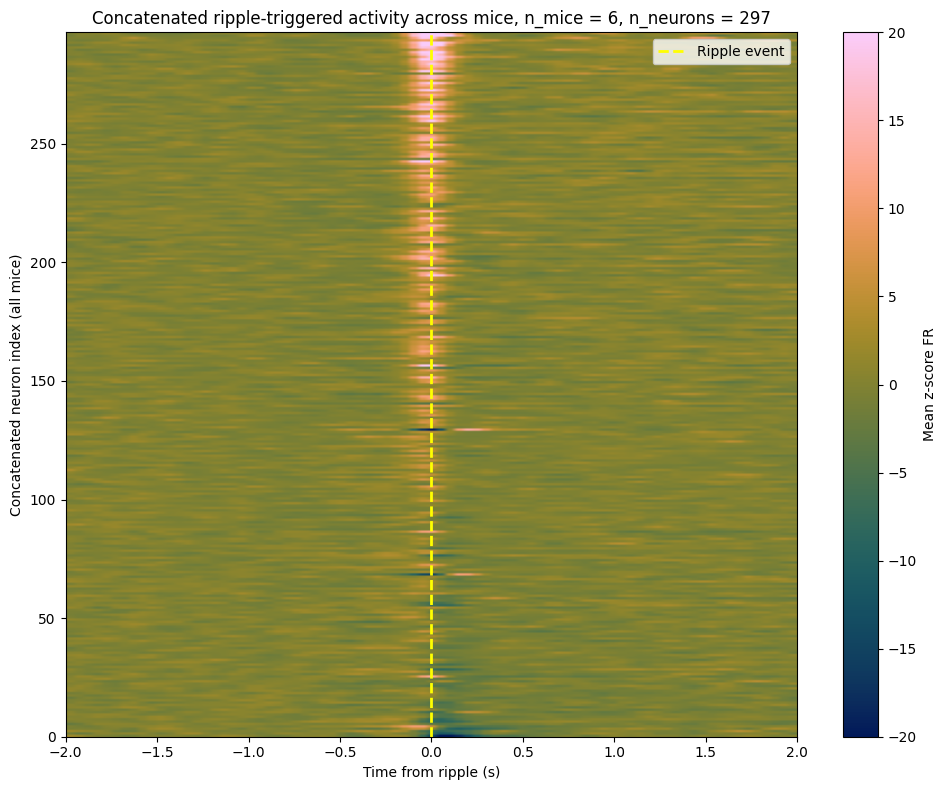

In [324]:
def plot_concatenated_ripple_heatmap(results_by_mouse, wi=2.0, cmap="cmc.batlow", sort = True, dir = None):
    blocks = []
    for mouse_label, result in results_by_mouse:
        hm = result["heatmap"][:, result["keep_sorted"]].T  # [neurons, time]
        if hm.shape[0] > 0:
            blocks.append(hm)

    if len(blocks) == 0:
        print("No valid mouse heatmaps to concatenate.")
        return

    concat_hm = np.vstack(blocks)
    time = np.linspace(-wi, wi, concat_hm.shape[1])
    if sort:
        times_mask = (time > -0.05) & (time < 1.5)
        sort_map = np.argsort(concat_hm[:, times_mask].mean(1))
        concat_hm = concat_hm[sort_map]

    plt.figure(figsize=(10, 8))
    plt.imshow(
        concat_hm,
        origin="lower",
        aspect="auto",
        extent=(-wi, wi, 0, concat_hm.shape[0]),
        cmap=cmap,
    )
    plt.colorbar(label="Mean z-score FR")
    plt.axvline(0, color="yellow", linestyle="--", linewidth=2, label="Ripple event")
    plt.xlabel("Time from ripple (s)")
    plt.ylabel("Concatenated neuron index (all mice)")
    plt.title(f"Concatenated ripple-triggered activity across mice, n_mice = {len(results_by_mouse)}, n_neurons = {concat_hm.shape[0]}")
    plt.legend(loc="upper right")
    plt.tight_layout()
    if dir is not None:
        plt.savefig(os.path.join(main_dir, "spike_data_RIPPLES.png"))
        plt.savefig(os.path.join(main_dir, "spike_data_RIPPLES.svg"))

    plt.show()

    return concat_hm

concat_hm = plot_concatenated_ripple_heatmap(results_by_mouse, dir = main_dir)

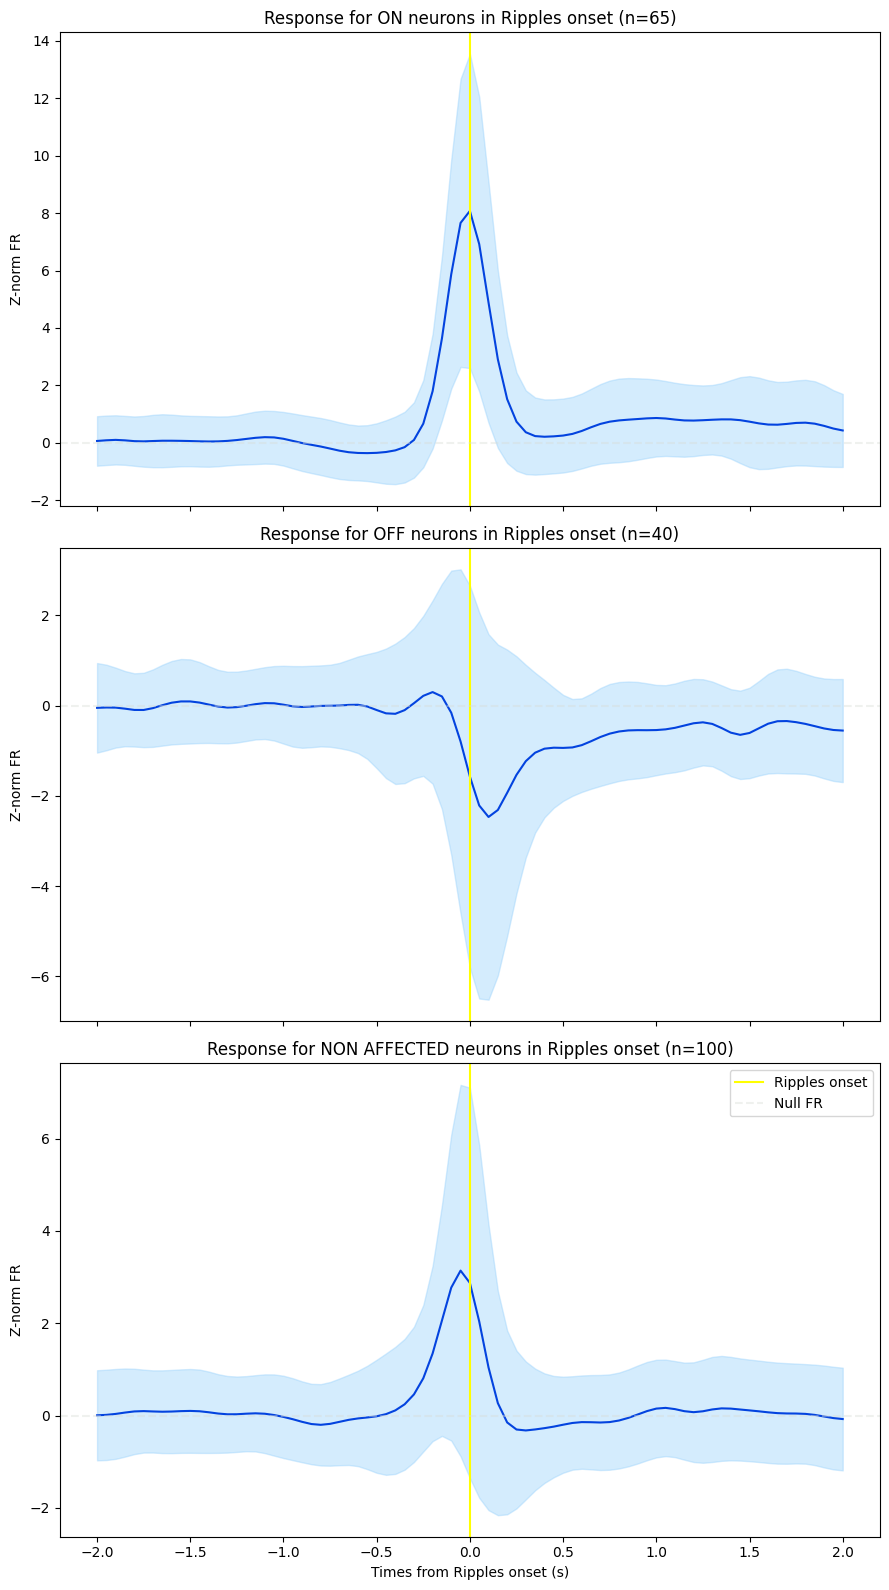

In [325]:
from scipy.ndimage import gaussian_filter

sigma = 1.5

time = np.linspace(-wi, wi, concat_hm.shape[1])
times_mask = (time >= -0.05) & (time <= 1.9)
sort_map = np.argsort(concat_hm[:, times_mask].mean(1))
concat_hm = concat_hm[sort_map]

freezing_response = concat_hm
on_neurons_freezing = sort_map[-65:]
off_neurons_freezing = sort_map[:40]
not_affected_neurons_freezing = sort_map[80:180]
on_response = freezing_response[on_neurons_freezing]
off_response = freezing_response[off_neurons_freezing]
no_response = freezing_response[not_affected_neurons_freezing]
# show mean response for on and off

fig, axs = plt.subplots(3, sharex = True, sharey = False, figsize = (9,16))
axs = axs.flatten()
times = np.linspace(- wi, wi, on_response.shape[1])
for i, (response, status) in enumerate(zip([on_response, off_response, no_response], ["on", "off", "non affected"])):
    mean = gaussian_filter(np.nanmean(response, axis=0), sigma = sigma)
    std = gaussian_filter(np.nanstd(response, axis=0), sigma = sigma)
    # first, plot individual traces in light grey
    # for resp in response:
    #     axs[i].plot(times, resp, color = "xkcd:light grey", alpha = 0.4)
    axs[i].plot(times, mean, color = "xkcd:blue")
    axs[i].fill_between(times, mean - 1*std, mean + 1*std, color = "xkcd:light blue", alpha = 0.4)
    axs[i].set_title(f"Response for {status.upper()} neurons in Ripples onset (n={response.shape[0]})")
    axs[i].axvline(0, label = "Ripples onset", color = "yellow")
    axs[i].set_ylabel("Z-norm FR")
    axs[i].axhline(0, label = "Null FR", linestyle = "--", alpha = 0.4, color = "xkcd:light grey")

axs[-1].set_xlabel("Times from Ripples onset (s)")
axs[-1].legend()
fig.tight_layout()
fig.savefig(os.path.join(
    main_dir, "neurons_ONOFF_ripples.png"
))

fig.savefig(os.path.join(
    main_dir, "neurons_ONOFF_ripples.svg"
))
plt.show()

## analyse spike data during shocks

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pynapple as nap

# ---------------------------
# Parameters
# ---------------------------
wi = 2.0  # window around event
bin_size = 0.05
smooth_sigma = 0.05
max_fr_thresh = 150.0  # Hz
min_std = 1e-3
clip_z = 20.0

# ---------------------------
# Helpers (unchanged from freezing pipeline)
# ---------------------------
def _safe_zscore_on_baseline(mean_ripple, baseline_mask,
                             min_std=1e-3, use_mad=True, clip_z=20.0, verbose=False):
    """
    Z-score ripple response using pre-window baseline (neuron-wise) but robust.
    """
    baseline = mean_ripple[baseline_mask, :]  # shape: [n_baseline_times, n_neurons]
    n_baseline = np.sum(baseline_mask)

    mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
    std_pre = np.nanstd(baseline, axis=0, keepdims=True)

    if use_mad:
        med = np.nanmedian(baseline, axis=0, keepdims=True)
        mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
        mad_std = 1.4826 * mad
    else:
        mad_std = np.full_like(std_pre, np.nan)

    combined = np.stack([
        np.where(np.isfinite(std_pre), std_pre, np.nan),
        np.where(np.isfinite(mad_std), mad_std, np.nan),
        np.full_like(std_pre, min_std)
    ], axis=0)
    with np.errstate(invalid="ignore"):
        std_final = np.nanmax(combined, axis=0)

    std_final = np.where(np.isfinite(std_final), std_final, min_std)

    mean_ripple_z = (mean_ripple - mean_pre) / std_final
    mean_ripple_z = np.clip(mean_ripple_z, -clip_z, clip_z)

    diagnostics = {
        "n_baseline_samples": int(n_baseline),
        "mean_pre_min": float(np.nanmin(mean_pre)) if np.isfinite(np.nanmin(mean_pre)) else np.nan,
        "mean_pre_max": float(np.nanmax(mean_pre)) if np.isfinite(np.nanmax(mean_pre)) else np.nan,
        "std_pre_min": float(np.nanmin(std_pre)) if np.isfinite(np.nanmin(std_pre)) else np.nan,
        "std_pre_median": float(np.nanmedian(std_pre)) if np.isfinite(np.nanmedian(std_pre)) else np.nan,
        "std_final_min": float(np.nanmin(std_final)) if np.isfinite(np.nanmin(std_final)) else np.nan,
        "n_neurons": mean_ripple.shape[1],
        "n_small_std": int(np.sum(std_final.flatten() <= min_std))
    }
    if verbose:
        print("Baseline samples:", diagnostics["n_baseline_samples"])
        print("mean_pre [min,max]:", diagnostics["mean_pre_min"], diagnostics["mean_pre_max"])
        print("std_pre [min,median]:", diagnostics["std_pre_min"], diagnostics["std_pre_median"])
        print("std_final_min:", diagnostics["std_final_min"], "n_small_std:", diagnostics["n_small_std"])

    return mean_ripple_z, diagnostics


def compute_stim_eta_for_mouse(
    mouse_results, wi=2.0, bin_size=0.05, smooth_sigma=0.05, max_fr_thresh=150.0
):
    """
    Compute event-triggered average (ETA) around stims events.
    Returns dict with:
      - heatmap: shape [time, n_neurons] (sorted by ripple response)
      - keep_sorted: bool mask of kept neurons in sorted order
      - sort_idx: sorting indices
      - n_neurons_raw
      - n_aberrant
    Neurons with max FR > max_fr_thresh (Hz) are treated as aberrant and excluded.
    """
    try:
        spikes = mouse_results.DataHelper.get_spike_data()
    except FileNotFoundError:
        if os.path.isfile(os.path.join(mouse_results.network_path, "SpikeData.mat")):
            print("copying spike data from server")
            import shutil
            shutil.copyfile(
                os.path.join(mouse_results.network_path, "SpikeData.mat"),
                os.path.join(mouse_results.DataHelper.folder, "SpikeData.mat"),
            )
            spikes = mouse_results.DataHelper.get_spike_data()
        else:
            raise

    cond_epoch = nap.IntervalSet(mouse_results.cond)

    # Get ripple timestamps
    try:
        stim_ts = nap.Ts(t = mouse_results.DataHelper.fullBehavior["Times"]["start_stim"].flatten())
    except (KeyError, AttributeError, TypeError):
        print("No ripple data available.")
        return None

    stim_ts = stim_ts.restrict(cond_epoch)
    if len(stim_ts) == 0:
        print("No ripples in conditioning epoch.")
        return None

    # Compute firing rate
    counts = spikes.count(bin_size)
    fr = counts / bin_size

    # Detect aberrant neurons (same as freezing pipeline)
    try:
        fr_values = fr.values.astype(float)
    except Exception:
        fr_values = np.array(fr).astype(float)

    n_neurons_raw = fr_values.shape[1] if fr_values.ndim == 2 else 0
    max_fr_per_neuron = np.nanmax(fr_values, axis=0)
    aberrant_mask = max_fr_per_neuron > max_fr_thresh
    n_aberrant = int(np.sum(aberrant_mask))
    valid_mask = ~aberrant_mask

    if valid_mask.sum() == 0:
        print("All neurons flagged as aberrant (FR > {}). skipping.".format(max_fr_thresh))
        return None

    z_fr = fr.smooth(smooth_sigma)

    # Compute ETA around ripple events
    eta = nap.compute_event_triggered_average(z_fr.restrict(cond_epoch), stim_ts,
                                               bin_size, window=(-wi, wi))

    # eta is TsdFrame: shape [time, neurons]
    mean_stims = eta.values.astype(float)
    mean_stims = mean_stims.reshape(mean_stims.shape[0], -1)
    mean_stims[np.isinf(mean_stims)] = np.nan

    # Set aberrant neurons to NaN
    if mean_stims.shape[1] != n_neurons_raw:
        n_neurons_raw = mean_stims.shape[1]
        max_fr_per_neuron = max_fr_per_neuron[:n_neurons_raw]
        valid_mask = max_fr_per_neuron <= max_fr_thresh
        aberrant_mask = ~valid_mask
        n_aberrant = int(np.sum(aberrant_mask))

    mean_stims[:, aberrant_mask] = np.nan

    t_eta = eta.times()
    baseline_mask = t_eta <= -0.5
    if not np.any(baseline_mask):
        print("No baseline samples (t <= -0.5). expanding baseline window.")
        baseline_mask = t_eta <= -0.1
    if not np.any(baseline_mask):
        return None

    mean_stims, diag = _safe_zscore_on_baseline(mean_stims, baseline_mask,
                                                  min_std=min_std, use_mad=True,
                                                  clip_z=clip_z, verbose=False)

    # Sort by ripple response in a middle window
    times_mask = (t_eta >= -0.05) & (t_eta <= 1.9)
    if not np.any(times_mask):
        return None

    sort_idx = np.argsort(np.nanmean(mean_stims[times_mask], axis=0))

    keep_neurons = ~np.isnan(mean_stims).all(axis=0)
    keep_neurons[aberrant_mask] = False

    sorted_heatmap = mean_stims[:, sort_idx]
    keep_sorted = keep_neurons[sort_idx]

    return {
        "heatmap": sorted_heatmap,
        "keep_sorted": keep_sorted,
        "sort_idx": sort_idx,
        "n_neurons_raw": int(n_neurons_raw),
        "n_aberrant": int(n_aberrant),
        "n_stims": len(stim_ts),
    }


def plot_stims_heatmap(result, mouse_label, wi=2.0, cmap="viridis"):
    hm = result["heatmap"]
    keep = result["keep_sorted"]
    hm_plot = hm[:, keep].T  # [neurons, time]

    plt.figure(figsize=(8, 6))
    plt.imshow(
        hm_plot,
        origin="lower",
        aspect="auto",
        extent=(-wi, wi, 0, hm_plot.shape[0]),
        cmap=cmap,
    )
    plt.colorbar(label="Mean z-score FR")
    plt.axvline(0, color="yellow", linestyle="--", linewidth=2, label="Ripple event")
    plt.xlabel("Time from stim PAG (s)")
    plt.ylabel("Neuron index (sorted)")
    plt.title(f"{mouse_label} - Ripple-triggered activity (n={result['n_stims']} stims)")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# ---------------------------
# Main loop over all mice
# ---------------------------
results_by_mouse = []

for (mouse, manipe), df in loader.results_df.groupby(["mouse", "manipe"]):
    mouse_results = df.iloc[0].results
    mouse_label = f"mouse {mouse} | {manipe}"

    out = compute_stim_eta_for_mouse(
        mouse_results,
        wi=wi,
        bin_size=bin_size,
        smooth_sigma=smooth_sigma,
        max_fr_thresh=max_fr_thresh,
    )
    if out is None:
        print(f"[skip] {mouse_label}: no valid stims/cond data")
        continue

    print(
        f"[ok] {mouse_label}: raw neurons={out['n_neurons_raw']}, "
        f"aberrant={out['n_aberrant']}, kept={out['keep_sorted'].sum()}, "
        f"ripples={out['n_stims']}"
    )
    results_by_mouse.append((mouse_label, out))

# 1) Plot per mouse
for mouse_label, out in results_by_mouse:
    plot_stims_heatmap(out, mouse_label, wi=wi, cmap="cmc.batlow")

/tmp/ipykernel_110208/887275027.py:27: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_110208/887275027.py:31: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_110208/887275027.py:32: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_110208/887275027.py:168: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_stims[times_mask], axis=0))


[ok] mouse 1162 | PAG: raw neurons=57, aberrant=19, kept=38, ripples=4


/tmp/ipykernel_110208/887275027.py:27: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_110208/887275027.py:31: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_110208/887275027.py:32: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_110208/887275027.py:168: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_stims[times_mask], axis=0))


[ok] mouse 1182 | PAG: raw neurons=51, aberrant=19, kept=32, ripples=5


/tmp/ipykernel_110208/887275027.py:27: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_110208/887275027.py:31: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_110208/887275027.py:32: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_110208/887275027.py:168: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_stims[times_mask], axis=0))


...

[ok] mouse 1239 | PAG: raw neurons=78, aberrant=23, kept=55, ripples=3


/tmp/ipykernel_110208/887275027.py:27: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_110208/887275027.py:31: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_110208/887275027.py:32: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_110208/887275027.py:168: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_stims[times_mask], axis=0))


[ok] mouse 905 | PAG: raw neurons=34, aberrant=8, kept=26, ripples=9


/tmp/ipykernel_110208/887275027.py:27: RuntimeWarning: Mean of empty slice
  mean_pre = np.nanmean(baseline, axis=0, keepdims=True)  # shape (1, n_neurons)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_110208/887275027.py:31: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(baseline, axis=0, keepdims=True)
/tmp/ipykernel_110208/887275027.py:32: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(baseline - med), axis=0, keepdims=True)
/tmp/ipykernel_110208/887275027.py:168: RuntimeWarning: Mean of empty slice
  sort_idx = np.argsort(np.nanmean(mean_stims[times_mask], axis=0))


[ok] mouse 994 | PAG: raw neurons=96, aberrant=19, kept=77, ripples=5


In [22]:
def plot_concatenated_stims_heatmap(results_by_mouse, wi=2.0, cmap="cmc.batlow", sort = True, dir = None):
    blocks = []
    for mouse_label, result in results_by_mouse:
        hm = result["heatmap"][:, result["keep_sorted"]].T  # [neurons, time]
        if hm.shape[0] > 0:
            blocks.append(hm)

    if len(blocks) == 0:
        print("No valid mouse heatmaps to concatenate.")
        return

    concat_hm = np.vstack(blocks)
    time = np.linspace(-wi, wi, concat_hm.shape[1])
    if sort:
        times_mask = (time > -0.05) & (time < 1.5)
        sort_map = np.argsort(concat_hm[:, times_mask].mean(1))
        concat_hm = concat_hm[sort_map]

    plt.figure(figsize=(10, 8))
    plt.imshow(
        concat_hm,
        origin="lower",
        aspect="auto",
        extent=(-wi, wi, 0, concat_hm.shape[0]),
        cmap=cmap,
    )
    plt.colorbar(label="Mean z-score FR")
    plt.axvline(0, color="yellow", linestyle="--", linewidth=2, label="PAG Stim event")
    plt.xlabel("Time from PAG stim (s)")
    plt.ylabel("Concatenated neuron index (all mice)")
    plt.title(f"Concatenated PAG stim-triggered activity across mice, n_mice = {len(results_by_mouse)}, n_neurons = {concat_hm.shape[0]}")
    plt.legend(loc="lower left")
    plt.tight_layout()
    if dir is not None:
        plt.savefig(os.path.join(dir, "spike_data_PAG_STIM.png"))
        plt.savefig(os.path.join(dir, "spike_data_PAG_STIM.svg"))

    plt.show()

    return concat_hm

concat_hm = plot_concatenated_stims_heatmap(results_by_mouse, dir = main_dir)

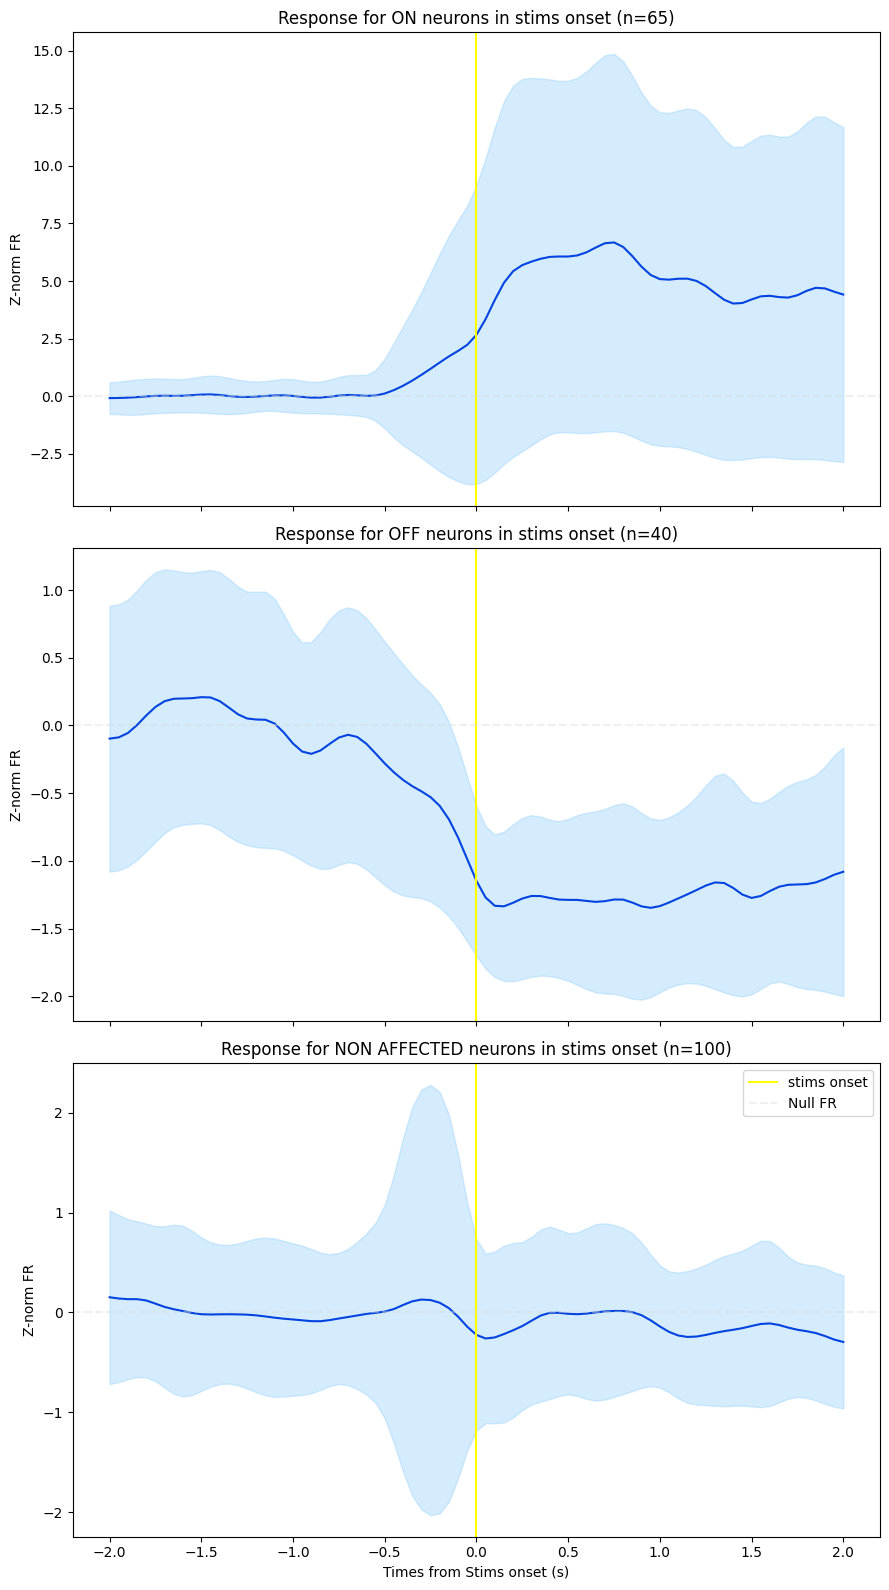

In [328]:
from scipy.ndimage import gaussian_filter

sigma = 1.5

time = np.linspace(-wi, wi, concat_hm.shape[1])
times_mask = (time >= -0.05) & (time <= 1.9)
sort_map = np.argsort(concat_hm[:, times_mask].mean(1))
concat_hm = concat_hm[sort_map]

freezing_response = concat_hm
on_neurons_freezing = sort_map[-65:]
off_neurons_freezing = sort_map[:40]
not_affected_neurons_freezing = sort_map[80:180]
on_response = freezing_response[on_neurons_freezing]
off_response = freezing_response[off_neurons_freezing]
no_response = freezing_response[not_affected_neurons_freezing]
# show mean response for on and off

fig, axs = plt.subplots(3, sharex = True, sharey = False, figsize = (9,16))
axs = axs.flatten()
times = np.linspace(- wi, wi, on_response.shape[1])
for i, (response, status) in enumerate(zip([on_response, off_response, no_response], ["on", "off", "non affected"])):
    mean = gaussian_filter(np.nanmean(response, axis=0), sigma = sigma)
    std = gaussian_filter(np.nanstd(response, axis=0), sigma = sigma)
    # first, plot individual traces in light grey
    # for resp in response:
    #     axs[i].plot(times, resp, color = "xkcd:light grey", alpha = 0.4)
    axs[i].plot(times, mean, color = "xkcd:blue")
    axs[i].fill_between(times, mean - 1*std, mean + 1*std, color = "xkcd:light blue", alpha = 0.4)
    axs[i].set_title(f"Response for {status.upper()} neurons in stims onset (n={response.shape[0]})")
    axs[i].axvline(0, label = "stims onset", color = "yellow")
    axs[i].set_ylabel("Z-norm FR")
    axs[i].axhline(0, label = "Null FR", linestyle = "--", alpha = 0.4, color = "xkcd:light grey")

axs[-1].set_xlabel("Times from Stims onset (s)")
axs[-1].legend()
fig.tight_layout()
fig.savefig(os.path.join(main_dir, "neurons_ONOFF_stims.png"))
fig.savefig(os.path.join(main_dir, "neurons_ONOFF_stims.svg"))

plt.show()